# Comparing FAVAR and Taylor Rule Models for Interest Rate Forecasting

**Master's Thesis — Quantitative Finance**

## Research question

Does augmenting a Nelson-Siegel VAR (NS-VAR) with macro factors (FAVAR) improve yield-curve forecasts?
Does FAVAR outperform a Taylor-rule-style macro-OLS benchmark?

## Five models compared

| Model | Description |
|-------|-------------|
| **Taylor-yield** | Primary benchmark: per-tenor expanding OLS on lagged yields + macro |
| **NS-VAR** | VAR(2) on differenced Nelson-Siegel [level, slope, curvature] |
| **FAVAR** | VAR(2) on NS factors + 3 PCA macro factors |
| **Diebold-Li** | Fixed-λ=0.0609 NS with VAR(1) factor dynamics |
| **Random Walk** | No-change benchmark |

## Dataset

- **Yields:** 11 US Treasury tenors (1M–30Y), 1980-01 to 2025-12, 552 monthly obs
- **Macro:** 35 FRED series → 25 pass 90% coverage filter → 3 PCA factors (53% variance)
- **Test window:** 2015-12 to 2025-12 (last 10 years, 119 months)


---
## 1. Setup and Data Collection

Import required libraries and fetch data from FRED.

In [1]:
import os
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Suppress statsmodels frequency/ValueWarning
import statsmodels
try:
    from statsmodels.tools.sm_exceptions import ValueWarning
    warnings.filterwarnings("ignore", category=ValueWarning)
except ImportError:
    pass
warnings.filterwarnings("ignore", message="No frequency information was provided")

# Data fetching
# import pandas_datareader.data as web

# Statistical modeling
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
from statsmodels.tsa.api import VAR

# Metrics
from sklearn.metrics import mean_squared_error

# Plot settings
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Define data parameters
START_DATE = '1980-01-01'
END_DATE = '2025-12-31'

# Extended Yield curve maturities (in months) for Nelson-Siegel
# Covers full curve from 1M to 30Y
YIELD_TICKERS = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']
MATURITIES = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]  # In years

# readable tenor labels (used for tables/plots)
TENOR_LABELS = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
YIELD_TICKER_TO_TENOR = dict(zip(YIELD_TICKERS, TENOR_LABELS))
DG_TO_TENOR = {f'DG{i+1}': TENOR_LABELS[i] for i in range(len(TENOR_LABELS))}

# Extended macro data tickers for yield curve prediction
MACRO_TICKERS = {
    'inflation': 'CPIAUCSL',           # CPI - inflation baseline
    'inflation_ex': 'CPILFESL',        # Core CPI - inflation excluding food and energy
    'output': 'INDPRO',                # Industrial Production
    'fedfunds': 'FEDFUNDS',            # Federal Funds Rate
    'fedfunds_eff': 'DFF',             # Effective Fed Funds Rate (daily)
    'unemployment': 'UNRATE',          # Unemployment Rate
    'payroll': 'PAYEMS',               # Nonfarm Payroll
    'retail_sales': 'RSXFS',           # Retail Sales ex auto and gas
    'housing': 'HOUST',                # Housing Starts
    'equity_market': 'SP500',          # S&P 500 Index
    'volatility': 'VIXCLS',            # VIX (Volatility Index)
    'hy_spread': 'BAMLH0A0HYM2',       # HY OAS spread (credit spreads)
    'credit_spread': 'BAMLH0A2HYC2',   # HY Option-Adjusted Spread
    'money_supply': 'M2SL',            # M2 Money Supply
    '5y_breakeven_inflation': 'T5YIE', # 5-Year Breakeven Inflation Rate
    'mortgage_rate': 'MORTGAGE30US',   # 30-year Mortgage Rate
}

print(f"Data period: {START_DATE} to {END_DATE}")
print(f"Extended yield tickers ({len(YIELD_TICKERS)} tenors): {YIELD_TICKERS}")
print(f"Tenor labels: {TENOR_LABELS}")
print(f"Extended macro tickers ({len(MACRO_TICKERS)} series): {list(MACRO_TICKERS.keys())}")

Data period: 1980-01-01 to 2025-12-31
Extended yield tickers (11 tenors): ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']
Tenor labels: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
Extended macro tickers (16 series): ['inflation', 'inflation_ex', 'output', 'fedfunds', 'fedfunds_eff', 'unemployment', 'payroll', 'retail_sales', 'housing', 'equity_market', 'volatility', 'hy_spread', 'credit_spread', 'money_supply', '5y_breakeven_inflation', 'mortgage_rate']


In [3]:
print("Loading extended yield curve data (1M-30Y)...")
yields_raw = pd.read_csv('../data/yields_raw.csv', index_col=0, parse_dates=True)
# Rename columns to human-readable tenors (affects all downstream tables/plots)
yields_raw = yields_raw.rename(columns=YIELD_TICKER_TO_TENOR).rename(columns=DG_TO_TENOR)
print(f"Yield data shape: {yields_raw.shape}")
print(f"Yield tickers loaded: {list(yields_raw.columns)}\n")

print("Loading extended macroeconomic data...")
macro_raw = pd.read_csv('../data/macro_raw.csv', index_col=0, parse_dates=False)
# Clean up macro_raw by dropping bad header rows if they exist
valid_dates = pd.to_datetime(macro_raw.index, errors='coerce')
macro_raw = macro_raw[valid_dates.notna()]
macro_raw.index = pd.to_datetime(macro_raw.index)
# Ensure columns are numeric
macro_raw = macro_raw.apply(pd.to_numeric, errors='coerce')

print(f"Macro data shape: {macro_raw.shape}")
print(f"Macro tickers loaded: {list(macro_raw.columns)}")

Loading extended yield curve data (1M-30Y)...
Yield data shape: (12002, 11)
Yield tickers loaded: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

Loading extended macroeconomic data...


Macro data shape: (16802, 35)
Macro tickers loaded: ['CPIAUCSL', 'CPILFESL', 'PCECTPI', 'PCEPILFE', 'PPIACO', 'PPIFGS', 'DCOILWTICO', 'T5YIE', 'MICH', 'FEDFUNDS', 'DFF', 'UNRATE', 'PAYEMS', 'UEMPMEAN', 'LNS14000025', 'ICSA', 'AWHNONAG', 'INDPRO', 'CUMFNS', 'DGORDER', 'RSXFS', 'HOUST', 'PERMIT', 'UMCSENT', 'M1SL', 'M2SL', 'BOGMBASE', 'SP500', 'VIXCLS', 'BAMLH0A0HYM2', 'BAA10YM', 'T10Y2Y', 'T10Y3M', 'MORTGAGE30US', 'DTWEXBGS']


In [4]:
# Preview raw data
print("Yield Data (first 5 rows):")
display(yields_raw.head())

print("\nMacro Data (first 5 rows):")
display(macro_raw.head())

Yield Data (first 5 rows):


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
DATE,,,,,,,,,,,
1980-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-02,NaN,NaN,NaN,11.89,11.39,10.77,10.52,10.51,10.50,10.23,10.23
1980-01-03,NaN,NaN,NaN,12.25,11.45,10.79,10.54,10.59,10.60,10.37,10.31
1980-01-04,NaN,NaN,NaN,12.25,11.47,10.81,10.62,10.63,10.66,10.42,10.34
1980-01-07,NaN,NaN,NaN,12.07,11.35,10.72,10.56,10.60,10.63,10.41,10.35



Macro Data (first 5 rows):


,CPIAUCSL,CPILFESL,PCECTPI,PCEPILFE,PPIACO,PPIFGS,DCOILWTICO,T5YIE,MICH,FEDFUNDS,...,M2SL,BOGMBASE,SP500,VIXCLS,BAMLH0A0HYM2,BAA10YM,T10Y2Y,T10Y3M,MORTGAGE30US,DTWEXBGS
DATE,,,,,,,,,,,,,,,,,,,,,
1980-01-01,78.0,76.7,37.545,36.315,85.2,83.4,NaN,NaN,10.4,13.82,...,1482.7,156.0,NaN,NaN,NaN,1.62,NaN,NaN,NaN,NaN
1980-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.89,NaN,NaN,NaN
1980-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.85,NaN,NaN,NaN
1980-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.81,NaN,12.85,NaN
1980-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Data Processing

Resample to monthly frequency, compute transformations, and align datasets.

In [5]:
def process_yields(yields_df):
    """
    Process yield data: resample to monthly and handle missing values.
    
    Parameters:
    -----------
    yields_df : pd.DataFrame
        Raw yield data
    
    Returns:
    --------
    pd.DataFrame
        Processed monthly yield data
    """
    if not isinstance(yields_df.index, pd.DatetimeIndex):
        yields_df.index = pd.to_datetime(yields_df.index)
        
    # Resample to monthly (end of month) using mean
    yields_monthly = yields_df.resample('ME').mean()
    
    # Forward fill then backward fill small gaps
    yields_monthly = yields_monthly.ffill().bfill()

    # Ensure human-readable tenor labels for downstream tables/plots
    yields_monthly = yields_monthly.rename(columns=YIELD_TICKER_TO_TENOR).rename(columns=DG_TO_TENOR)
    
    return yields_monthly


def process_macro(macro_df):
    """
    Process macro data: resample to monthly, apply appropriate transformations.
    Level series: rates, spreads, indices, sentiment.
    Flow series: log-differenced and annualised (x1200 for monthly).
    """
    if not isinstance(macro_df.index, pd.DatetimeIndex):
        macro_df.index = pd.to_datetime(macro_df.index)
    macro_monthly = macro_df.resample("ME").mean()
    processed = pd.DataFrame(index=macro_monthly.index)

    # --- Price level series (log-diff, annualised) ---
    for col, name in [("CPIAUCSL", "inflation"), ("CPILFESL", "inflation_core"),
                      ("PCECTPI", "pce_inflation"), ("PCEPILFE", "pce_core"),
                      ("PPIACO", "ppi_all"), ("PPIFGS", "ppi_finished"),
                      ("DCOILWTICO", "oil_price")]:
        if col in macro_monthly.columns:
            processed[name] = np.log(macro_monthly[col]).diff() * 1200

    # --- Activity: output & employment (log-diff, annualised) ---
    for col, name in [("INDPRO", "output"), ("PAYEMS", "payroll"),
                      ("RSXFS", "retail_sales"), ("HOUST", "housing"),
                      ("CUMFNS", "capacity_util"), ("DGORDER", "durable_goods"),
                      ("PERMIT", "permits"), ("SP500", "equity_return"),
                      ("M2SL", "money_growth"), ("M1SL", "m1_growth"),
                      ("BOGMBASE", "monetary_base"), ("DTWEXBGS", "usd_index"),
                      ("ICSA", "init_claims")]:
        if col in macro_monthly.columns:
            processed[name] = np.log(macro_monthly[col]).diff() * 1200

    # --- Level series: rates, spreads, indices, sentiment ---
    for col, name in [("FEDFUNDS", "fedfunds"), ("DFF", "fedfunds_eff"),
                      ("UNRATE", "unrate"), ("UEMPMEAN", "unemp_duration"),
                      ("LNS14000025", "unrate_prime"), ("AWHNONAG", "avg_hours"),
                      ("T5YIE", "breakeven_inflation"),
                      ("MORTGAGE30US", "mortgage_rate"),
                      ("VIXCLS", "volatility"),
                      ("BAMLH0A0HYM2", "hy_spread"), ("BAMLH0A2HYC2", "credit_spread"),
                      ("BAA10YM", "baa_spread"),
                      ("T10Y2Y", "term_spread_10y2y"), ("T10Y3M", "term_spread_10y3m"),
                      ("MICH", "sentiment_mich"), ("UMCSENT", "sentiment_umcs")]:
        if col in macro_monthly.columns:
            processed[name] = macro_monthly[col]

    return processed


# Process data
yields_monthly = process_yields(yields_raw)
macro_processed = process_macro(macro_raw)

print("Processed yields shape:", yields_monthly.shape)
print("Processed yields columns:", list(yields_monthly.columns))
print("\nProcessed macro shape:", macro_processed.shape)
print("Processed macro columns:", list(macro_processed.columns))

Processed yields shape: (552, 11)
Processed yields columns: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

Processed macro shape: (552, 35)
Processed macro columns: ['inflation', 'inflation_core', 'pce_inflation', 'pce_core', 'ppi_all', 'ppi_finished', 'oil_price', 'output', 'payroll', 'retail_sales', 'housing', 'capacity_util', 'durable_goods', 'permits', 'equity_return', 'money_growth', 'm1_growth', 'monetary_base', 'usd_index', 'init_claims', 'fedfunds', 'fedfunds_eff', 'unrate', 'unemp_duration', 'unrate_prime', 'avg_hours', 'breakeven_inflation', 'mortgage_rate', 'volatility', 'hy_spread', 'baa_spread', 'term_spread_10y2y', 'term_spread_10y3m', 'sentiment_mich', 'sentiment_umcs']


In [6]:
# Align datasets by common dates
common_index = yields_monthly.index.intersection(macro_processed.index)
yields_aligned = yields_monthly.loc[common_index]
macro_aligned = macro_processed.loc[common_index]

# Yields: enforce no missing values (we filled small gaps already)
yields_aligned = yields_aligned.dropna()

# Macro: keep missing values here; PCA step will select high-coverage variables
# and drop rows only for those selected variables.

# Final alignment (after yield dropping)
common_index = yields_aligned.index.intersection(macro_aligned.index)
yields_aligned = yields_aligned.loc[common_index]
macro_aligned = macro_aligned.loc[common_index]

print(f"Final aligned dataset:")
print(f"  Date range: {common_index[0].strftime('%Y-%m')} to {common_index[-1].strftime('%Y-%m')}")
print(f"  Number of observations: {len(common_index)}")
print(f"  Yields shape: {yields_aligned.shape}")
print(f"  Macro shape: {macro_aligned.shape}")
print(f"  Macro missingness (avg % missing): {macro_aligned.isna().mean().mean()*100:.2f}%")

Final aligned dataset:
  Date range: 1980-01 to 2025-12
  Number of observations: 552
  Yields shape: (552, 11)
  Macro shape: (552, 35)
  Macro missingness (avg % missing): 12.57%


In [7]:
# Summary statistics
print("="*70)
print("EXTENDED YIELD CURVE DATA (1M - 30Y)")
print("="*70)
print("\nYield Data Summary:")
display(yields_aligned.describe().round(2))

print("\n" + "="*70)
print("EXTENDED MACROECONOMIC DATA")
print("="*70)
print("\nMacro Data Summary (First 15 variables):")
macro_summary = macro_aligned.describe().round(2)
display(macro_summary.iloc[:, :min(15, len(macro_summary.columns))])

if len(macro_summary.columns) > 15:
    print(f"\n... and {len(macro_summary.columns) - 15} more variables")
    print(f"Total macro variables: {len(macro_summary.columns)}")

EXTENDED YIELD CURVE DATA (1M - 30Y)

Yield Data Summary:


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
count,552.00,552.00,552.00,552.00,552.00,552.00,552.00,552.00,552.00,552.00,552.00
mean,2.60,4.26,4.45,4.47,4.74,4.90,5.21,5.45,5.63,5.89,6.03
std,1.67,3.79,3.93,3.68,3.69,3.63,3.50,3.40,3.30,3.03,3.02
min,0.00,0.01,0.04,0.05,0.12,0.16,0.27,0.46,0.62,1.06,1.27
25%,0.91,0.95,1.09,1.25,1.57,1.67,2.34,2.81,3.00,3.74,3.77
50%,3.67,4.31,4.30,4.29,4.33,4.42,4.56,4.69,4.73,5.29,5.21
75%,3.67,5.84,6.08,6.22,6.62,6.78,7.06,7.26,7.47,7.28,7.85
max,5.57,15.61,16.36,16.72,16.46,16.22,15.93,15.65,15.32,15.13,14.68



EXTENDED MACROECONOMIC DATA

Macro Data Summary (First 15 variables):


,inflation,inflation_core,pce_inflation,pce_core,ppi_all,ppi_finished,oil_price,output,payroll,retail_sales,housing,capacity_util,durable_goods,permits,equity_return
count,549.00,549.00,0.0,551.00,551.00,431.00,479.00,551.00,551.00,407.00,551.00,551.00,406.00,551.00,116.00
mean,3.12,3.20,NaN,2.74,2.44,2.31,2.32,1.46,1.21,4.41,0.07,-0.22,3.05,0.28,12.29
std,3.49,2.43,NaN,2.05,11.69,6.94,115.28,11.75,8.11,19.40,97.67,13.43,52.93,68.72,42.97
min,-21.44,-5.89,NaN,-6.84,-65.76,-36.90,-681.83,-169.71,-174.93,-153.87,-368.09,-197.29,-286.36,-328.85,-253.87
25%,1.49,1.86,NaN,1.42,-2.32,-0.96,-59.17,-3.12,0.47,-1.74,-56.36,-5.14,-20.35,-34.34,-2.71
50%,2.93,2.67,NaN,2.26,2.36,2.49,13.04,2.16,1.62,4.76,-2.05,0.36,4.18,-0.72,18.70
75%,4.59,4.02,NaN,3.55,7.87,5.92,67.25,6.44,2.60,11.13,58.46,4.70,32.23,38.98,36.99
max,16.59,16.91,NaN,11.90,37.94,22.64,655.02,76.17,41.06,201.38,308.06,90.68,280.79,313.44,94.81



... and 20 more variables
Total macro variables: 35


---
## 3. Nelson-Siegel Model

Implement the Nelson-Siegel (1987) model to extract yield curve factors:
- **Level (β₀)**: Long-term interest rate level
- **Slope (β₁)**: Yield curve slope
- **Curvature (β₂)**: Yield curve curvature

The model is:
$$y(\tau) = \beta_0 + \beta_1 \left(\frac{1 - e^{-\tau/\lambda}}{\tau/\lambda}\right) + \beta_2 \left(\frac{1 - e^{-\tau/\lambda}}{\tau/\lambda} - e^{-\tau/\lambda}\right)$$

In [8]:
def nelson_siegel(tau, beta0, beta1, beta2, lam):
    """
    Nelson-Siegel yield curve model.
    
    Parameters:
    -----------
    tau : float or array
        Maturity in years
    beta0 : float
        Level factor (long-term rate)
    beta1 : float
        Slope factor
    beta2 : float
        Curvature factor
    lam : float
        Decay parameter (lambda/tau)
    
    Returns:
    --------
    float or array
        Fitted yield(s)
    """
    tau = np.asarray(tau)
    
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        decay = tau / lam
        exp_decay = np.exp(-decay)
        
        # Loading for slope factor
        loading1 = np.where(decay != 0, (1 - exp_decay) / decay, 1.0)
        
        # Loading for curvature factor
        loading2 = loading1 - exp_decay
    
    return beta0 + beta1 * loading1 + beta2 * loading2


def fit_nelson_siegel(yields, maturities):
    """
    Fit Nelson-Siegel model to observed yields.
    
    Parameters:
    -----------
    yields : array
        Observed yields for different maturities
    maturities : array
        Corresponding maturities in years
    
    Returns:
    --------
    dict
        Fitted parameters (beta0, beta1, beta2, lambda)
    """
    maturities = np.array(maturities)
    yields = np.array(yields)
    
    def objective(params):
        beta0, beta1, beta2, lam = params
        fitted = nelson_siegel(maturities, beta0, beta1, beta2, lam)
        return np.sum((yields - fitted) ** 2)
    
    # Initial guesses based on yield curve characteristics
    # beta0: long rate, beta1: short - long, beta2: medium - average
    y_short = yields[0] if len(yields) > 0 else 2.0
    y_long = yields[-1] if len(yields) > 0 else 4.0
    
    initial_guess = [
        y_long,           # beta0 (level)
        y_short - y_long, # beta1 (slope)
        0.0,              # beta2 (curvature)
        1.5               # lambda (decay)
    ]
    
    # Bounds for optimization
    bounds = [
        (-10, 20),   # beta0
        (-15, 15),   # beta1
        (-15, 15),   # beta2
        (0.1, 10)    # lambda (must be positive)
    ]
    
    result = minimize(
        objective,
        initial_guess,
        method='L-BFGS-B',
        bounds=bounds
    )
    
    return {
        'beta0': result.x[0],
        'beta1': result.x[1],
        'beta2': result.x[2],
        'lambda': result.x[3],
        'success': result.success,
        'rmse': np.sqrt(result.fun / len(yields))
    }

In [9]:
def extract_ns_factors(yields_df, maturities):
    """
    Extract Nelson-Siegel factors for entire time series.

    Parameters:
    -----------
    yields_df : pd.DataFrame
        Yield data with dates as index
    maturities : list
        Maturities in years

    Returns:
    --------
    pd.DataFrame
        DataFrame with level, slope, curvature factors (and lambda, fit RMSE)
    """
    results = []

    for date in yields_df.index:
        yields = yields_df.loc[date].values

        # Skip if any yields are missing
        if np.any(np.isnan(yields)):
            results.append({
                'date': date,
                'level': np.nan,
                'slope': np.nan,
                'curvature': np.nan,
                'lambda': np.nan,
                'ns_fit_rmse': np.nan,
            })
            continue

        # Fit NS model
        params = fit_nelson_siegel(yields, maturities)

        results.append({
            'date': date,
            'level': params['beta0'],
            'slope': params['beta1'],
            'curvature': params['beta2'],
            'lambda': params['lambda'],
            'ns_fit_rmse': params['rmse'],
        })

    factors_df = pd.DataFrame(results).set_index('date')
    return factors_df


# Extract NS factors (this may take a minute)
print("Extracting Nelson-Siegel factors...")
ns_factors = extract_ns_factors(yields_aligned, MATURITIES)
print("Done!")

print(f"\nNelson-Siegel factors shape: {ns_factors.shape}")
display(ns_factors.head(10))

Extracting Nelson-Siegel factors...


Done!

Nelson-Siegel factors shape: (552, 5)


,level,slope,curvature,lambda,ns_fit_rmse
date,,,,,
1980-01-31,11.173713,-8.185181,15.0,0.158054,2.101917
1980-02-29,13.093587,-12.658616,15.0,0.129837,1.816634
1980-03-31,13.871200,-13.580657,15.0,0.132989,1.873677
1980-04-30,12.160829,-10.151240,15.0,0.147533,1.962696
1980-05-31,10.217178,-7.367403,15.0,0.146808,2.374032
1980-06-30,9.541045,-6.244046,15.0,0.149593,2.551496
1980-07-31,9.973882,-7.125098,15.0,0.144699,2.474871
1980-08-31,11.162879,-9.351829,15.0,0.136413,2.182665
1980-09-30,11.879010,-10.562566,15.0,0.134060,2.006818


In [10]:
# Summary statistics for NS factors
print("Nelson-Siegel Factors Summary:")
display(ns_factors.describe().round(3))

Nelson-Siegel Factors Summary:


,level,slope,curvature,lambda,ns_fit_rmse
count,552.000,552.000,552.000,552.000,552.000
mean,6.201,-4.696,0.681,1.466,0.244
std,2.922,3.978,5.560,1.474,0.382
min,1.765,-15.000,-7.214,0.100,0.011
25%,4.245,-5.305,-3.260,0.134,0.045
50%,5.621,-3.815,-0.000,1.217,0.095
75%,7.726,-2.204,1.433,2.253,0.289
max,15.806,1.487,15.000,10.000,2.551


---
## 4. PCA for Macro Factors

Apply Principal Component Analysis to macro variables to extract latent factors.

In [11]:
def extract_pca_factors(macro_df, n_components=3):
    """
    Extract PCA factors from macro variables.
    Automatically selects variables with sufficient data coverage.
    
    Parameters:
    -----------
    macro_df : pd.DataFrame
        Processed macro data
    n_components : int
        Number of principal components to extract
    
    Returns:
    --------
    tuple
        (factors_df, pca_object, scaler_object, explained_variance_ratios, selected_variables)
    """
    # Select variables with good data coverage (>90% non-missing)
    data = macro_df.copy()
    coverage = 1 - (data.isna().sum() / len(data))
    
    # Use variables with >90% coverage
    selected_vars = coverage[coverage > 0.90].index.tolist()
    
    print(f"Variables selected for PCA ({len(selected_vars)}):")
    for var in selected_vars:
        print(f"  {var:25s}: {coverage[var]*100:.1f}% coverage")
    
    data_selected = data[selected_vars].copy()
    
    # Drop rows with any missing values
    data_selected = data_selected.dropna()
    
    # Standardize the data
    scaler = StandardScaler()
    data_standardized = scaler.fit_transform(data_selected)
    
    # Apply PCA
    pca = PCA(n_components=min(n_components, len(selected_vars)))
    factors = pca.fit_transform(data_standardized)
    
    # Create DataFrame with factors
    factor_names = [f'F{i+1}' for i in range(pca.n_components_)]
    factors_df = pd.DataFrame(
        factors,
        index=data_selected.index,
        columns=factor_names
    )
    
    return factors_df, pca, scaler, pca.explained_variance_ratio_, selected_vars


# Extract PCA factors (increased to 3 components with extended macro data)
pca_factors, pca_model, scaler, variance_ratios, selected_macro_vars = extract_pca_factors(
    macro_aligned, n_components=3
)

print("\n" + "="*60)
print("PCA Factors extracted successfully!")
print("="*60)
print(f"\nExplained Variance Ratios:")
for i, ratio in enumerate(variance_ratios):
    print(f"  F{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")
print(f"  Total: {sum(variance_ratios):.4f} ({sum(variance_ratios)*100:.2f}%)")

Variables selected for PCA (25):
  inflation                : 99.5% coverage
  inflation_core           : 99.5% coverage
  pce_core                 : 99.8% coverage
  ppi_all                  : 99.8% coverage
  output                   : 99.8% coverage
  payroll                  : 99.8% coverage
  housing                  : 99.8% coverage
  capacity_util            : 99.8% coverage
  permits                  : 99.8% coverage
  money_growth             : 99.8% coverage
  m1_growth                : 99.8% coverage
  monetary_base            : 99.8% coverage
  init_claims              : 99.8% coverage
  fedfunds                 : 100.0% coverage
  fedfunds_eff             : 100.0% coverage
  unrate                   : 99.8% coverage
  unemp_duration           : 99.8% coverage
  unrate_prime             : 99.8% coverage
  avg_hours                : 100.0% coverage
  mortgage_rate            : 100.0% coverage
  baa_spread               : 100.0% coverage
  term_spread_10y2y        : 100.0% co

In [12]:
# Show PCA loadings
factor_cols = [f'F{i+1}' for i in range(pca_model.n_components_)]
loadings = pd.DataFrame(
    pca_model.components_.T,
    columns=factor_cols,
    index=selected_macro_vars
)

print("\nPCA Factor Loadings:")
print("(Higher absolute values indicate stronger contributions to each factor)")
print("="*60)
display(loadings.round(4))


PCA Factor Loadings:
(Higher absolute values indicate stronger contributions to each factor)


,F1,F2,F3
inflation,0.1980,0.1788,0.0235
inflation_core,0.2703,0.0586,0.1138
pce_core,0.2445,0.0756,0.1745
ppi_all,0.0915,0.2321,-0.0039
output,0.1416,0.3815,-0.0125
payroll,0.1506,0.3554,-0.0645
housing,0.0374,0.1974,0.0408
capacity_util,0.1116,0.4138,0.0161
permits,0.0268,0.1924,0.0659
money_growth,-0.1267,-0.2017,0.1596


In [13]:
# Preview PCA factors
print("PCA Factors (first 10 rows):")
display(pca_factors.head(10))

PCA Factors (first 10 rows):


,F1,F2,F3
DATE,,,
1982-01-31,3.521385,-3.543791,4.202089
1982-02-28,6.068126,0.021339,4.231326
1982-03-31,3.607499,-2.637984,4.288263
1982-04-30,4.797061,-3.216259,4.984736
1982-05-31,5.249458,-1.225985,5.126824
1982-06-30,5.329847,-1.925564,5.071222
1982-07-31,4.719877,-0.176772,5.845869
1982-08-31,1.883477,-2.631758,5.415961
1982-09-30,1.394055,-0.961132,5.515227


### 4b. Expanded Macro Panel (Data-Rich, ~30 Series)

After re-fetching data via `fetch_data.ipynb`, `macro_raw.csv` now contains ~30 FRED series.  The main pipeline above already processes them all into `macro_aligned`.  Here we extract **4** principal components from that richer panel, aligning with ECB WP 544 which uses 4 macro factors.

In [14]:
# Extract 4 macro factors from the expanded macro_aligned panel
N_MACRO_FACTORS_EXP = 4

pca_fac_exp, pca_obj_exp, scaler_exp, var_ratios_exp, sel_vars_exp = \
    extract_pca_factors(macro_aligned, n_components=N_MACRO_FACTORS_EXP)

print(f'Expanded macro panel: {macro_aligned.shape[1]} series available')
print(f'Series selected (coverage ≥ 90%): {len(sel_vars_exp)}')
print(f'\nPCA — {N_MACRO_FACTORS_EXP} components:')
for i, r in enumerate(var_ratios_exp, 1):
    print(f'  PC{i}: {r*100:.2f}%')
print(f'  Total explained: {sum(var_ratios_exp)*100:.2f}%')
print(f'  (Original 3-factor explained: {sum(variance_ratios)*100:.2f}%)')


Variables selected for PCA (25):
  inflation                : 99.5% coverage
  inflation_core           : 99.5% coverage
  pce_core                 : 99.8% coverage
  ppi_all                  : 99.8% coverage
  output                   : 99.8% coverage
  payroll                  : 99.8% coverage
  housing                  : 99.8% coverage
  capacity_util            : 99.8% coverage
  permits                  : 99.8% coverage
  money_growth             : 99.8% coverage
  m1_growth                : 99.8% coverage
  monetary_base            : 99.8% coverage
  init_claims              : 99.8% coverage
  fedfunds                 : 100.0% coverage
  fedfunds_eff             : 100.0% coverage
  unrate                   : 99.8% coverage
  unemp_duration           : 99.8% coverage
  unrate_prime             : 99.8% coverage
  avg_hours                : 100.0% coverage
  mortgage_rate            : 100.0% coverage
  baa_spread               : 100.0% coverage
  term_spread_10y2y        : 100.0% co

In [15]:
# KEY4 MACRO PCA — focused 4-series macro panel
# Motivated by Caldeira et al. (2023, CEA@Bayes WP-07-2023):
#   macro variables matter most at long maturities.
# Series: CPI inflation, Fed Funds, Unemployment, Industrial Production

KEY4_VARS = ['inflation', 'fedfunds', 'unrate', 'output']
key4_available = [v for v in KEY4_VARS if v in macro_aligned.columns]
print(f'Key4 macro series available: {key4_available}')

key4_data = macro_aligned[key4_available].dropna()
_scaler_k4 = StandardScaler()
key4_scaled = pd.DataFrame(
    _scaler_k4.fit_transform(key4_data),
    index=key4_data.index, columns=key4_data.columns
)

N_KEY4_FACTORS = min(2, len(key4_available))
_pca_k4 = PCA(n_components=N_KEY4_FACTORS)
pca_key4_factors = pd.DataFrame(
    _pca_k4.fit_transform(key4_scaled),
    index=key4_data.index,
    columns=[f'K4F{i+1}' for i in range(N_KEY4_FACTORS)]
)

print(f'\nKey4 PCA ({N_KEY4_FACTORS} factors from {len(key4_available)} core macro series):')
for i, r in enumerate(_pca_k4.explained_variance_ratio_, 1):
    print(f'  PC{i}: {r*100:.2f}%')
print(f'  Total: {sum(_pca_k4.explained_variance_ratio_)*100:.2f}%')

_ldf = pd.DataFrame(_pca_k4.components_.T, index=key4_available,
                    columns=[f'K4F{i+1}' for i in range(N_KEY4_FACTORS)])
print(f'\nKey4 loadings:\n{_ldf.round(3).to_string()}')
print(f'pca_key4_factors shape: {pca_key4_factors.shape}')


Key4 macro series available: ['inflation', 'fedfunds', 'unrate', 'output']

Key4 PCA (2 factors from 4 core macro series):
  PC1: 35.46%
  PC2: 26.98%
  Total: 62.43%

Key4 loadings:
            K4F1   K4F2
inflation  0.693 -0.141
fedfunds   0.659  0.271
unrate     0.120  0.717
output     0.266 -0.627
pca_key4_factors shape: (549, 2)


---
## 5. FAVAR Model

Combine Nelson-Siegel factors with PCA macro factors and estimate a VAR model.

In [16]:
# Combine NS factors and PCA factors
# (keep only level/slope/curvature in the state vector)
favar_data = pd.concat([ns_factors[['level', 'slope', 'curvature']], pca_factors], axis=1)
favar_data = favar_data.dropna()

print("Combined FAVAR data:")
print(f"  Shape: {favar_data.shape}")
print(f"  Columns: {list(favar_data.columns)}")
display(favar_data.head())

Combined FAVAR data:
  Shape: (526, 6)
  Columns: ['level', 'slope', 'curvature', 'F1', 'F2', 'F3']


,level,slope,curvature,F1,F2,F3
1982-01-31,14.520840,-15.0,15.0,3.521385,-3.543791,4.202089
1982-02-28,14.621987,-15.0,15.0,6.068126,0.021339,4.231326
1982-03-31,13.961213,-15.0,15.0,3.607499,-2.637984,4.288263
1982-04-30,13.940508,-15.0,15.0,4.797061,-3.216259,4.984736
1982-05-31,13.603902,-15.0,15.0,5.249458,-1.225985,5.126824


In [17]:
# Difference the data to ensure stationarity
favar_diff = favar_data.diff().dropna()

print("Differenced FAVAR data:")
print(f"  Shape: {favar_diff.shape}")
display(favar_diff.head())

Differenced FAVAR data:
  Shape: (525, 6)


,level,slope,curvature,F1,F2,F3
1982-02-28,0.101147,0.0,0.0,2.546741,3.565130,0.029237
1982-03-31,-0.660774,0.0,0.0,-2.460627,-2.659323,0.056937
1982-04-30,-0.020706,0.0,0.0,1.189562,-0.578275,0.696472
1982-05-31,-0.336606,0.0,0.0,0.452397,1.990274,0.142089
1982-06-30,0.687878,0.0,0.0,0.080389,-0.699579,-0.055602


In [18]:
def split_data(data, train_ratio=0.8, split_date=None, test_years=None):
    """
    Split data into training and testing sets.

    Options:
    - Ratio-based split (default): first train_ratio for training.
    - Date-based split: provide split_date (test starts at split_date).
    - Last-N-years test split: provide test_years.

    Parameters:
    -----------
    data : pd.DataFrame
        Input data with a DatetimeIndex
    train_ratio : float
        Proportion of data for training (used if split_date/test_years not provided)
    split_date : str | pd.Timestamp | None
        Test period starts at this date (inclusive)
    test_years : int | None
        Length of test window in years (from the end of the sample)

    Returns:
    --------
    tuple
        (train_data, test_data, split_index)
    """
    if not isinstance(data.index, pd.DatetimeIndex):
        raise TypeError("split_data expects a DatetimeIndex")

    if test_years is not None:
        split_date = (data.index.max() - pd.DateOffset(years=int(test_years))) + pd.offsets.MonthEnd(0)

    if split_date is not None:
        split_date = pd.to_datetime(split_date)
        train = data.loc[data.index < split_date]
        test = data.loc[data.index >= split_date]
        if len(test) == 0 or len(train) == 0:
            raise ValueError("Invalid split: train or test is empty. Adjust split_date/test_years.")
        return train, test, len(train)

    n = len(data)
    split_idx = int(n * train_ratio)
    train = data.iloc[:split_idx]
    test = data.iloc[split_idx:]
    return train, test, split_idx


# Split the data (paper-style pseudo out-of-sample: last N years as test)
TEST_YEARS = 10
train_diff, test_diff, split_idx = split_data(favar_diff, test_years=TEST_YEARS)
split_date = test_diff.index.min()

print(f"Train set: {len(train_diff)} observations ({train_diff.index[0].strftime('%Y-%m')} to {train_diff.index[-1].strftime('%Y-%m')})")
print(f"Test set:  {len(test_diff)} observations ({test_diff.index[0].strftime('%Y-%m')} to {test_diff.index[-1].strftime('%Y-%m')})")
print(f"Split date (test start): {split_date.strftime('%Y-%m')}")

Train set: 406 observations (1982-02 to 2015-11)
Test set:  119 observations (2015-12 to 2025-12)
Split date (test start): 2015-12


In [19]:
def fit_var_model(train_data, lags=2):
    """Fit a VAR(lags) model to training data."""
    model = VAR(train_data)
    results = model.fit(lags)
    return results


# VAR lag order (keep fixed for comparability)
VAR_LAGS = 2
print(f"Using VAR lag order: {VAR_LAGS}")

Using VAR lag order: 2


---
## 6. Forecast Function Definitions

Defines all forecasting functions used in the multi-horizon evaluation:
- `recursive_var_forecast_refit` — expanding-window VAR (FAVAR / NS-VAR)
- `factors_to_yields` — NS factor → yield reconstruction
- `recursive_taylor_yield_forecast` — direct h-step OLS per tenor
- `random_walk_forecast`, `recursive_yield_var_forecast`, `recursive_dl_yield_forecast` — ECB-style benchmarks
- `compute_rmse`, `compute_mae`, `metrics_by_tenor`, `build_rmse_summary` — evaluation

In [20]:
def recursive_var_forecast_refit(train_data, test_data, lags=2, horizon=1):
    """Expanding-window VAR forecast with configurable horizon.

    For horizon=1 this is a standard 1-step-ahead expanding-window VAR.
    For horizon>1 (h-step ahead), returns the CUMULATIVE diff over h periods
    so that: level_forecast[t+h] = ns_lag[origin] + returned_value.

    Parameters
    ----------
    train_data : pd.DataFrame
    test_data : pd.DataFrame
        Out-of-sample segment (forecast origins AND realized values for
        the expanding window).
    lags : int
    horizon : int
        Forecast horizon in periods (months).

    Returns
    -------
    pd.DataFrame
        horizon=1: forecasts indexed at each test date.
        horizon>1: cumulative h-step diff forecasts indexed at target
        dates (origin_date + horizon - 1 months, month-end aligned).
    """
    train_data = train_data.dropna().copy()
    test_data = test_data.dropna().copy()

    common_cols = [c for c in train_data.columns if c in test_data.columns]
    if len(common_cols) == 0:
        raise ValueError("No common columns between train_data and test_data")

    train_data = train_data[common_cols]
    test_data = test_data[common_cols]

    history = train_data.copy()
    forecasts = []
    target_dates = []

    for date in test_data.index:
        if len(history) <= lags:
            raise ValueError("Not enough history to fit VAR with the requested lag order")

        results = VAR(history).fit(lags)
        y_last = history.values[-lags:]
        all_steps = results.forecast(y_last, steps=horizon)   # shape (horizon, n_vars)

        if horizon == 1:
            fc = all_steps[0]
            target_dates.append(date)
        else:
            # Cumulative sum = total change over h periods
            fc = all_steps.cumsum(axis=0)[-1]
            target = (date + pd.DateOffset(months=horizon - 1)) + pd.offsets.MonthEnd(0)
            target_dates.append(target)

        forecasts.append(fc)
        history = pd.concat([history, test_data.loc[[date]]], axis=0)

    return pd.DataFrame(forecasts, index=target_dates, columns=common_cols)

def factors_to_yields(factors_df, maturities, yield_cols, lam):
    """Convert Nelson–Siegel factors to yields at the given maturities.

    factors_df must have columns: ['level', 'slope', 'curvature'].

    lam can be:
    - scalar (same lambda for all dates), or
    - array-like of length len(factors_df) (date-varying lambda).
    """
    beta0 = factors_df['level'].to_numpy(dtype=float)
    beta1 = factors_df['slope'].to_numpy(dtype=float)
    beta2 = factors_df['curvature'].to_numpy(dtype=float)

    lam_arr = np.asarray(lam, dtype=float)
    if lam_arr.ndim == 0:
        lam_arr = np.full(len(factors_df), float(lam_arr))
    if len(lam_arr) != len(factors_df):
        raise ValueError("lam must be scalar or have the same length as factors_df")

    out = pd.DataFrame(index=factors_df.index, columns=yield_cols, dtype=float)

    for tau, col in zip(maturities, yield_cols):
        x = float(tau) / lam_arr  # fixed: match estimation form exp(-tau/lambda)
        with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
            term1 = (1.0 - np.exp(-x)) / x
        term1 = np.where(x == 0.0, 1.0, term1)
        term2 = term1 - np.exp(-x)
        out[col] = beta0 + beta1 * term1 + beta2 * term2

    return out


def recursive_taylor_yield_forecast(macro_df, yields_df, yield_cols, split_date, horizon=1):
    """Expanding-window OLS yield forecasts using only t-horizon information.

    For each maturity (yield column), estimates an expanding-window regression:
        y_t(m) = a + b' x_{t-h} + rho * y_{t-h}(m) + eps_t
    where h = horizon.

    For horizon=1 this is identical to the original 1-step OLS.
    For horizon>1 this is a direct h-step-ahead regression using predictors
    lagged by h periods (no look-ahead) and with the *refit window* ending
    at the forecast origin (t-h).

    Note: With the expanded macro panel, we restrict regressors to high-coverage
    series to avoid shrinking the sample to the intersection of many sparse
    predictors.
    """
    # Strict Taylor (1993) rule: inflation, output gap, Fed Funds rate only
    # Not the full 25-variable macro panel — keeps the benchmark clean and interpretable
    TAYLOR_VARS = ['inflation', 'output', 'fedfunds']
    macro_cols = [v for v in TAYLOR_VARS if v in macro_df.columns]

    macro_use = macro_df[macro_cols].copy()
    macro_lag = macro_use.shift(horizon)
    yields_lag = yields_df.shift(horizon)

    dates = yields_df.index
    test_dates = dates[dates >= split_date]

    forecasts = pd.DataFrame(index=test_dates, columns=yield_cols, dtype=float)

    X_cols = ['y_lag'] + macro_cols

    for col in yield_cols:
        parts = [yields_df[col], yields_lag[col]]
        if len(macro_cols) > 0:
            parts.append(macro_lag)
        df = pd.concat(parts, axis=1).dropna()
        df.columns = ['y', 'y_lag'] + macro_cols

        for t in test_dates:
            if t not in df.index:
                continue

            # Forecast origin is t-horizon (month-end aligned)
            origin = (t - pd.DateOffset(months=horizon)) + pd.offsets.MonthEnd(0)

            # Refit expanding window *only* on data available at the origin (no look-ahead)
            train_df = df.loc[df.index <= origin]
            if len(train_df) < 36:
                continue

            X = train_df[X_cols]
            X = sm.add_constant(X)
            y = train_df['y']
            model = sm.OLS(y, X).fit()

            X_t = df.loc[[t], X_cols]
            X_t = sm.add_constant(X_t, has_constant='add')
            forecasts.loc[t, col] = float(model.predict(X_t).iloc[0])

    return forecasts


# --- Model 1: FAVAR (NS factors + PCA macro factors) ---
favar_forecasts_diff = recursive_var_forecast_refit(train_diff, test_diff, lags=VAR_LAGS)

# --- Model 2: NS-VAR (NS factors only) ---
ns_levels = ns_factors[['level', 'slope', 'curvature']].dropna()
ns_diff = ns_levels.diff().dropna()
train_ns_diff, test_ns_diff, _ = split_data(ns_diff, split_date=split_date)
nsvar_forecasts_diff = recursive_var_forecast_refit(train_ns_diff, test_ns_diff, lags=VAR_LAGS)

print("Forecasts generated!")
print(f"  FAVAR diff forecast shape: {favar_forecasts_diff.shape}")
print(f"  NS-VAR diff forecast shape: {nsvar_forecasts_diff.shape}")

# --- Evaluate on a common test index (intersection across models + yields) ---
yield_cols = list(yields_aligned.columns)

test_dates = test_diff.index.intersection(nsvar_forecasts_diff.index).intersection(yields_aligned.index)

# --- Convert 1-step diff forecasts to level forecasts (paper-style evaluation in levels) ---
ns_lag = ns_levels.shift(1).loc[test_dates]
ns_actual = ns_levels.loc[test_dates]

favar_ns_diff_fc = favar_forecasts_diff.reindex(test_dates)[['level', 'slope', 'curvature']]
nsvar_ns_diff_fc = nsvar_forecasts_diff.reindex(test_dates)[['level', 'slope', 'curvature']]

ns_forecast_levels_favar = ns_lag + favar_ns_diff_fc
ns_forecast_levels_nsvar = ns_lag + nsvar_ns_diff_fc

# --- Yield-curve forecasts (reconstruct yields from factor forecasts) ---
# Use persistence for lambda: \hat{lambda}_t = lambda_{t-1}
lam_series = ns_factors['lambda'].dropna()
lam_lag = lam_series.shift(1).reindex(test_dates)

# If any lambda values are missing (rare), fall back to median lambda
lam_lag = lam_lag.fillna(lam_series.median())

yields_actual_test = yields_aligned.loc[test_dates, yield_cols]

yields_forecast_favar = factors_to_yields(ns_forecast_levels_favar, MATURITIES, yield_cols, lam=lam_lag.values)
yields_forecast_nsvar = factors_to_yields(ns_forecast_levels_nsvar, MATURITIES, yield_cols, lam=lam_lag.values)

# Taylor Rule benchmark: per-tenor OLS with strict Taylor variables
yields_forecast_taylor_full = recursive_taylor_yield_forecast(
    macro_df=macro_aligned,
    yields_df=yields_aligned,
    yield_cols=yield_cols,
    split_date=split_date,
 )
yields_forecast_taylor = yields_forecast_taylor_full.reindex(test_dates)[yield_cols]

print(f"  Common test window: {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')}")
print(f"  Test sample: {yields_actual_test.shape[0]} months")
print(f"  Yield maturities: {len(yield_cols)}")
print(f"  Lambda (median): {lam_series.median():.4f}")


Forecasts generated!
  FAVAR diff forecast shape: (119, 6)
  NS-VAR diff forecast shape: (121, 3)


  Common test window: 2015-12 to 2025-12
  Test sample: 119 months
  Yield maturities: 11
  Lambda (median): 1.2172


In [21]:
# =============================================================================
# STEP 2: BENCHMARK FUNCTIONS
# =============================================================================

# 2a. Random Walk (no-change)
def random_walk_forecast(yields_df, yield_cols, split_date, horizon=1):
    """h-step-ahead random walk: forecast = yield observed h periods ago."""
    test_dates = yields_df.index[yields_df.index >= split_date]
    return yields_df[yield_cols].shift(horizon).reindex(test_dates)


# 2b. VAR on yield levels
def recursive_yield_var_forecast(yields_df, yield_cols, split_date, lags=1, horizon=1):
    """Expanding-window VAR(lags) on yield LEVELS; iterated h-step forecast."""
    data    = yields_df[yield_cols].dropna()
    history = data.loc[data.index < split_date].copy()
    test    = data.loc[data.index >= split_date]
    forecasts, target_dates = [], []
    for date in test.index:
        if len(history) <= lags:
            break
        res    = VAR(history).fit(lags)
        y_last = history.values[-lags:]
        fc     = res.forecast(y_last, steps=horizon)[-1]
        forecasts.append(fc)
        if horizon == 1:
            target_dates.append(date)
        else:
            target_dates.append(
                (date + pd.DateOffset(months=horizon - 1)) + pd.offsets.MonthEnd(0)
            )
        history = pd.concat([history, test.loc[[date]]], axis=0)
    return pd.DataFrame(forecasts, index=target_dates, columns=yield_cols)


# 2c. Diebold-Li (2005) with fixed lambda
DL_LAMBDA = 0.0609  # peak slope loading at ~30-month maturity (Diebold-Li 2006)

def dl_ns_loadings(maturities, lam=DL_LAMBDA):
    """Return (level, slope, curvature) loadings for fixed-lambda NS."""
    tau = np.array(maturities, dtype=float)
    x   = tau / lam
    with np.errstate(divide='ignore', invalid='ignore'):
        sl = np.where(x == 0.0, 1.0, (1.0 - np.exp(-x)) / x)
    cl = sl - np.exp(-x)
    return np.ones_like(tau), sl, cl


def fit_dl_factors(yields_df, yield_cols, maturities, lam=DL_LAMBDA):
    """OLS-fit Diebold-Li NS factors each month with fixed lambda."""
    L, S, C = dl_ns_loadings(maturities, lam)
    X = np.column_stack([L, S, C])
    records = []
    for date, row in yields_df[yield_cols].iterrows():
        y = row.values.astype(float)
        mask = ~np.isnan(y)
        if mask.sum() < 3:
            records.append({'date': date, 'level': float('nan'),
                            'slope': float('nan'), 'curvature': float('nan')})
            continue
        beta, *_ = np.linalg.lstsq(X[mask], y[mask], rcond=None)
        records.append({'date': date, 'level': beta[0], 'slope': beta[1], 'curvature': beta[2]})
    return pd.DataFrame(records).set_index('date')


def dl_factors_to_yields(factors_df, maturities, yield_cols, lam=DL_LAMBDA):
    """Reconstruct yields from Diebold-Li factors (fixed lambda)."""
    L, S, C = dl_ns_loadings(maturities, lam)
    b0 = factors_df['level'].values
    b1 = factors_df['slope'].values
    b2 = factors_df['curvature'].values
    out = pd.DataFrame(index=factors_df.index, columns=yield_cols, dtype=float)
    for j, col in enumerate(yield_cols):
        out[col] = b0 * L[j] + b1 * S[j] + b2 * C[j]
    return out


def recursive_dl_yield_forecast(yields_df, yield_cols, maturities, split_date,
                                 lam=DL_LAMBDA, lags=1, horizon=1):
    """Diebold-Li: expanding-window VAR(lags) on DL factors; h-step forecast."""
    dl_fac    = fit_dl_factors(yields_df, yield_cols, maturities, lam)
    fac_train = dl_fac.loc[dl_fac.index < split_date].dropna()
    fac_test  = dl_fac.loc[dl_fac.index >= split_date].dropna()
    history   = fac_train.copy()
    fac_fcs, target_dates = [], []
    for date in fac_test.index:
        if len(history) <= lags:
            break
        res    = VAR(history).fit(lags)
        y_last = history.values[-lags:]
        fc     = res.forecast(y_last, steps=horizon)[-1]
        fac_fcs.append(fc)
        if horizon == 1:
            target_dates.append(date)
        else:
            target_dates.append(
                (date + pd.DateOffset(months=horizon - 1)) + pd.offsets.MonthEnd(0)
            )
        history = pd.concat([history, fac_test.loc[[date]]], axis=0)
    fc_fac = pd.DataFrame(fac_fcs, index=target_dates, columns=dl_fac.columns)
    return dl_factors_to_yields(fc_fac, maturities, yield_cols, lam)


print('Benchmark functions defined: RandomWalk, YieldVAR, Diebold-Li')
print(f'  Diebold-Li fixed lambda: {DL_LAMBDA}')

# 2d. NS-RW: Nelson-Siegel Random Walk (Caldeira et al. 2023, Sec 4.1)
# Non-stationary factor assumption (Phi=I): each NS beta follows a RW.
# Forecast: beta_{t+h|t} = beta_t, lambda_{t+h|t} = lambda_t.
# Yields reconstructed via NS — distinct from raw-yield RW because NS
# imposes a smooth cross-maturity constraint and propagates time-varying lambda.
def ns_rw_yield_forecast(ns_factors_df, yields_df, yield_cols, maturities,
                          split_date, horizon=1):
    test_dates = yields_df.index[yields_df.index >= split_date]
    tau = np.array(maturities, dtype=float)
    forecasts = []
    for target in test_dates:
        origin_approx = (target - pd.DateOffset(months=horizon)) + pd.offsets.MonthEnd(0)
        avail = ns_factors_df.index[ns_factors_df.index <= origin_approx]
        if len(avail) == 0:
            forecasts.append([np.nan] * len(yield_cols))
            continue
        origin = avail[-1]
        b0  = ns_factors_df.loc[origin, 'level']
        b1  = ns_factors_df.loc[origin, 'slope']
        b2  = ns_factors_df.loc[origin, 'curvature']
        lam = ns_factors_df.loc[origin, 'lambda']
        x   = tau / lam
        with np.errstate(divide='ignore', invalid='ignore'):
            sl = np.where(x == 0.0, 1.0, (1.0 - np.exp(-x)) / x)
        cl = sl - np.exp(-x)
        forecasts.append((b0 + b1 * sl + b2 * cl).tolist())
    return pd.DataFrame(forecasts, index=test_dates, columns=yield_cols)

print('NS-RW function defined (Caldeira et al. 2023 non-stationary insight)')


Benchmark functions defined: RandomWalk, YieldVAR, Diebold-Li
  Diebold-Li fixed lambda: 0.0609
NS-RW function defined (Caldeira et al. 2023 non-stationary insight)


In [22]:
def compute_rmse(actual, predicted):
    # Root Mean Squared Error, dropping NaN pairs
    aligned = pd.concat([actual.rename('actual'), predicted.rename('pred')], axis=1).dropna()
    if len(aligned) == 0:
        return np.nan
    return float(np.sqrt(mean_squared_error(aligned['actual'], aligned['pred'])))


def compute_mae(actual, predicted):
    # Mean Absolute Error, dropping NaN pairs
    aligned = pd.concat([actual.rename('actual'), predicted.rename('pred')], axis=1).dropna()
    if len(aligned) == 0:
        return np.nan
    return float(np.mean(np.abs(aligned['actual'] - aligned['pred'])))


def win_rate(actual, fc_a, fc_b):
    # Share of dates where model A is closer to actual than model B (absolute error)
    df = pd.concat([
        actual.rename('actual'),
        fc_a.rename('a'),
        fc_b.rename('b'),
    ], axis=1).dropna()
    if len(df) == 0:
        return np.nan
    err_a = (df['actual'] - df['a']).abs()
    err_b = (df['actual'] - df['b']).abs()
    return float((err_a < err_b).mean())


def metrics_by_tenor(y_actual: pd.DataFrame, forecasts: dict):
    # Per-tenor RMSE and MAE for a dict of model forecasts
    tenors = list(y_actual.columns)
    model_names = list(forecasts.keys())
    rmse_df = pd.DataFrame(index=tenors, columns=model_names, dtype=float)
    mae_df  = pd.DataFrame(index=tenors, columns=model_names, dtype=float)
    for tenor in tenors:
        for name, fc in forecasts.items():
            rmse_df.loc[tenor, name] = compute_rmse(y_actual[tenor], fc[tenor])
            mae_df.loc[tenor, name]  = compute_mae(y_actual[tenor], fc[tenor])
    return rmse_df, mae_df


print(f"Evaluation window: {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')} ({len(test_dates)} months)")

# --- NS factor RMSE (level, slope, curvature) ---
# Compares how accurately each model captures Nelson-Siegel factor dynamics
factor_rmse_df = pd.DataFrame(
    index=['level', 'slope', 'curvature'],
    columns=['NS-VAR', 'FAVAR'],
    dtype=float
)
for fac in factor_rmse_df.index:
    factor_rmse_df.loc[fac, 'NS-VAR'] = compute_rmse(ns_actual[fac], ns_forecast_levels_nsvar[fac])
    factor_rmse_df.loc[fac, 'FAVAR']  = compute_rmse(ns_actual[fac], ns_forecast_levels_favar[fac])
print("NS factor RMSE (levels):")
display(factor_rmse_df.round(4))

# --- FAVAR-Key4 h=1 forecast ---
# NS factors + 2 PCA factors extracted from the focused 4-series macro panel:
#   CPI inflation, Federal Funds rate, Unemployment rate, Industrial Production
# Motivated by Caldeira et al. (2023): focused macro variables outperform broad panel
_k4_data  = pd.concat([ns_factors[['level','slope','curvature']], pca_key4_factors], axis=1).dropna()
_k4_diff  = _k4_data.diff().dropna()
_k4_train, _k4_test, _ = split_data(_k4_diff, split_date=split_date)
_k4_fc    = recursive_var_forecast_refit(_k4_train, _k4_test, lags=VAR_LAGS)
_k4_dates = _k4_test.index.intersection(test_dates)
_k4_ns_lag = ns_levels.shift(1).reindex(_k4_dates)
_k4_fc_ns  = _k4_ns_lag + _k4_fc.reindex(_k4_dates)[['level','slope','curvature']]
_k4_lam    = lam_series.shift(1).reindex(_k4_dates).fillna(lam_series.median())
yields_forecast_favar_key4 = factors_to_yields(
    _k4_fc_ns, MATURITIES, yield_cols, lam=_k4_lam.values
).reindex(test_dates)

# ==========================================================================
# h=1 MODEL REGISTRY — 4 core models for tenor-by-tenor comparison
# ==========================================================================
# Taylor Rule : per-tenor OLS using strict Taylor (1993) variables
#               (inflation, output gap, Fed Funds lag) — PRIMARY BENCHMARK
# NS-VAR      : Nelson-Siegel factors [level, slope, curvature] in VAR(2)
# FAVAR       : NS factors + 3 PCA macro factors (full 25-series panel), VAR(2)
# FAVAR-Key4  : NS factors + 2 PCA factors from {CPI, FEDFUNDS, UNRATE, IP}, VAR(2)
yield_model_forecasts = {
    'Taylor Rule': yields_forecast_taylor,
    'NS-VAR':      yields_forecast_nsvar,
    'FAVAR':       yields_forecast_favar,
    'FAVAR-Key4':  yields_forecast_favar_key4,
}

# Best FAVAR for headline comparison: FAVAR-Key4
# Confirmed by multi-horizon analysis — lowest avg RMSE among FAVAR variants at h=1, 6, 12
best_favar_overall = 'FAVAR-Key4'
yields_forecast_favar_best = yield_model_forecasts['FAVAR-Key4']

# --- h=1 RMSE and MAE by tenor ---
yield_rmse_ft_df, yield_mae_ft_df = metrics_by_tenor(yields_actual_test, yield_model_forecasts)

# Pairwise win-rates vs Taylor Rule benchmark
yield_winrate_vs_taylor = pd.DataFrame(
    index=yield_cols,
    columns=[c for c in yield_model_forecasts.keys() if c != 'Taylor Rule'],
    dtype=float
)
for tenor in yield_cols:
    for name in yield_winrate_vs_taylor.columns:
        yield_winrate_vs_taylor.loc[tenor, name] = win_rate(
            yields_actual_test[tenor],
            yield_model_forecasts[name][tenor],
            yield_model_forecasts['Taylor Rule'][tenor]
        )

print("\nYield RMSE by tenor (h=1, levels):")
display(yield_rmse_ft_df.round(4))

print("\nYield MAE by tenor:")
display(yield_mae_ft_df.round(4))

# RMSE ratios vs Taylor Rule benchmark (<1 means better than Taylor Rule)
diag_cols = [c for c in yield_model_forecasts.keys() if c != 'Taylor Rule']
rmse_ratio_vs_taylor = (
    yield_rmse_ft_df[diag_cols]
    .div(yield_rmse_ft_df['Taylor Rule'], axis=0)
    .add_prefix('RMSE(').add_suffix(')/RMSE(Taylor Rule)')
)
mae_ratio_vs_taylor = (
    yield_mae_ft_df[diag_cols]
    .div(yield_mae_ft_df['Taylor Rule'], axis=0)
    .add_prefix('MAE(').add_suffix(')/MAE(Taylor Rule)')
)
summary_ft = pd.concat([rmse_ratio_vs_taylor, mae_ratio_vs_taylor], axis=1)
for name in diag_cols:
    summary_ft[f"P(|e_{name}| < |e_TaylorRule|)"] = yield_winrate_vs_taylor[name]

print("\nDiagnostics vs Taylor Rule benchmark (<1 favors alternative model):")
display(summary_ft.round(4))

avg_table = pd.DataFrame({
    'Avg RMSE': yield_rmse_ft_df.mean(axis=0),
    'Avg MAE':  yield_mae_ft_df.mean(axis=0),
}).T
print("\nAverage metrics across tenors:")
display(avg_table.round(4))


Evaluation window: 2015-12 to 2025-12 (119 months)
NS factor RMSE (levels):


,NS-VAR,FAVAR
level,0.2005,0.2258
slope,0.3416,0.4316
curvature,1.1314,1.2094



Yield RMSE by tenor (h=1, levels):


,Taylor Rule,NS-VAR,FAVAR,FAVAR-Key4
1M,0.2425,0.3013,0.3779,0.3479
3M,0.2070,0.2662,0.3381,0.3147
6M,0.2057,0.2752,0.3342,0.3186
1Y,0.2511,0.2566,0.3099,0.2949
2Y,0.2474,0.2330,0.2870,0.2637
3Y,0.2415,0.2249,0.2818,0.2511
5Y,0.2317,0.2072,0.2703,0.2287
7Y,0.2236,0.2004,0.2661,0.2198
10Y,0.2149,0.1872,0.2519,0.2055
20Y,0.1962,0.2313,0.2669,0.2475



Yield MAE by tenor:


,Taylor Rule,NS-VAR,FAVAR,FAVAR-Key4
1M,0.1274,0.1804,0.2612,0.2085
3M,0.1163,0.1709,0.2373,0.1967
6M,0.1196,0.1909,0.2443,0.2157
1Y,0.1411,0.1802,0.2230,0.2038
2Y,0.1571,0.1599,0.1943,0.1794
3Y,0.1612,0.1570,0.1901,0.1731
5Y,0.1646,0.1557,0.1868,0.1652
7Y,0.1638,0.1569,0.1863,0.1631
10Y,0.1589,0.1445,0.1790,0.1515
20Y,0.1498,0.1782,0.1971,0.1871



Diagnostics vs Taylor Rule benchmark (<1 favors alternative model):


,RMSE(NS-VAR)/RMSE(Taylor Rule),RMSE(FAVAR)/RMSE(Taylor Rule),RMSE(FAVAR-Key4)/RMSE(Taylor Rule),MAE(NS-VAR)/MAE(Taylor Rule),MAE(FAVAR)/MAE(Taylor Rule),MAE(FAVAR-Key4)/MAE(Taylor Rule),P(|e_NS-VAR| < |e_TaylorRule|),P(|e_FAVAR| < |e_TaylorRule|),P(|e_FAVAR-Key4| < |e_TaylorRule|)
1M,1.2425,1.5583,1.4346,1.4167,2.0508,1.6372,0.2373,0.1949,0.2203
3M,1.2862,1.6333,1.5202,1.4686,2.0394,1.6907,0.2458,0.2034,0.2373
6M,1.3382,1.6249,1.5489,1.5967,2.0432,1.8038,0.2712,0.1695,0.1949
1Y,1.0221,1.2343,1.1744,1.2770,1.5797,1.4441,0.3559,0.2034,0.2966
2Y,0.9418,1.1601,1.0659,1.0184,1.2370,1.1423,0.4492,0.3898,0.3814
3Y,0.9313,1.1669,1.0395,0.9744,1.1795,1.0742,0.5254,0.3814,0.4237
5Y,0.8942,1.1664,0.9869,0.9458,1.1353,1.0038,0.4915,0.3983,0.4661
7Y,0.8961,1.1900,0.9830,0.9574,1.1371,0.9955,0.4746,0.4661,0.5000
10Y,0.8710,1.1721,0.9562,0.9093,1.1268,0.9533,0.5763,0.3983,0.5254
20Y,1.1788,1.3604,1.2615,1.1902,1.3164,1.2495,0.3729,0.3898,0.4068



Average metrics across tenors:


,Taylor Rule,NS-VAR,FAVAR,FAVAR-Key4
Avg RMSE,0.2235,0.2335,0.2912,0.2636
Avg MAE,0.1459,0.1655,0.2059,0.1817


---
## 7. Multi-Horizon Forecast Runs  (h = 1, 6, 12 months)

Runs **all six models** at three forecast horizons:

| Model | Type |
|-------|------|
| **Taylor Rule**  | Per-tenor OLS: inflation + output gap + Fed Funds (PRIMARY BENCHMARK) |
| **Random Walk**  | No-change benchmark |
| **NS-VAR**       | Nelson-Siegel factors [level, slope, curvature] in VAR(2) |
| **NS-RW**        | NS factors with random-walk dynamics (Caldeira et al. 2023) |
| **FAVAR**        | NS factors + 3 PCA macro factors (full 25-series panel), VAR(2) |
| **FAVAR-Key4**   | NS factors + 2 PCA factors from {CPI, FEDFUNDS, UNRATE, IP}, VAR(2) |
| **Diebold-Li**   | Fixed-lambda Nelson-Siegel + VAR(1) dynamics |
| **Yield-VAR**    | VAR(1) on raw yield levels |

Results stored in `multi_horizon_forecasts[h]` and `multi_horizon_actuals[h]`.

In [23]:
# =============================================================================
# STEP 1: MULTI-HORIZON FORECAST RUNS  (h = 1, 6, 12)
# =============================================================================

HORIZONS = [1, 6, 12]
multi_horizon_forecasts = {}
multi_horizon_actuals   = {}

for h in HORIZONS:
    print(f'\n{"="*60}')
    print(f'  Horizon h = {h} month(s)')
    print(f'{"="*60}')

    # FAVAR: iterated h-step cumulative diff forecast
    print(f'  FAVAR h={h}...', end=' ', flush=True)
    fc_diff_h  = recursive_var_forecast_refit(train_diff, test_diff, lags=VAR_LAGS, horizon=h)
    orig_favar = (fc_diff_h.index - pd.DateOffset(months=h - 1)).map(
        lambda d: d + pd.offsets.MonthEnd(0))
    ns_lag_fav = ns_levels.shift(1).reindex(orig_favar).set_axis(fc_diff_h.index)
    lam_lag_fav = (ns_factors['lambda'].shift(1).reindex(orig_favar)
                   .fillna(ns_factors['lambda'].median()).set_axis(fc_diff_h.index))
    ns_fc_fav  = ns_lag_fav + fc_diff_h[['level', 'slope', 'curvature']]
    fc_favar_h = factors_to_yields(ns_fc_fav, MATURITIES, yield_cols, lam=lam_lag_fav.values)
    print('done')

    # NS-VAR: iterated h-step cumulative diff forecast
    print(f'  NS-VAR h={h}...', end=' ', flush=True)
    fc_ns_h    = recursive_var_forecast_refit(train_ns_diff, test_ns_diff, lags=VAR_LAGS, horizon=h)
    orig_nsvar = (fc_ns_h.index - pd.DateOffset(months=h - 1)).map(
        lambda d: d + pd.offsets.MonthEnd(0))
    ns_lag_nsv = ns_levels.shift(1).reindex(orig_nsvar).set_axis(fc_ns_h.index)
    lam_lag_nsv = (ns_factors['lambda'].shift(1).reindex(orig_nsvar)
                   .fillna(ns_factors['lambda'].median()).set_axis(fc_ns_h.index))
    ns_fc_nsv  = ns_lag_nsv + fc_ns_h[['level', 'slope', 'curvature']]
    fc_nsvar_h = factors_to_yields(ns_fc_nsv, MATURITIES, yield_cols, lam=lam_lag_nsv.values)
    print('done')

    # Taylor-yield: direct h-step OLS
    print(f'  Taylor h={h}...', end=' ', flush=True)
    fc_taylor_h = recursive_taylor_yield_forecast(
        macro_df=macro_aligned, yields_df=yields_aligned,
        yield_cols=yield_cols, split_date=split_date, horizon=h)
    print('done')

    # Random Walk
    fc_rw_h = random_walk_forecast(yields_aligned, yield_cols, split_date, horizon=h)

    # Yield-only VAR
    print(f'  Yield-VAR h={h}...', end=' ', flush=True)
    fc_yvar_h = recursive_yield_var_forecast(
        yields_aligned, yield_cols, split_date, lags=1, horizon=h)
    print('done')

    # Diebold-Li
    print(f'  Diebold-Li h={h}...', end=' ', flush=True)
    fc_dl_h = recursive_dl_yield_forecast(
        yields_aligned, yield_cols, MATURITIES, split_date, lags=1, horizon=h)
    print('done')

    # NS-RW: non-stationary NS factors (Caldeira et al. 2023)
    print(f'  NS-RW h={h}...', end=' ', flush=True)
    fc_nsrw_h = ns_rw_yield_forecast(
        ns_factors, yields_aligned, yield_cols, MATURITIES, split_date, horizon=h)
    print('done')

    # FAVAR-Key4: focused macro panel (CPI, Fed Funds, UNRATE, IP)
    print(f'  FAVAR-Key4 h={h}...', end=' ', flush=True)
    _kd = pd.concat([ns_factors[['level','slope','curvature']], pca_key4_factors], axis=1).dropna()
    _kd_diff = _kd.diff().dropna()
    _ktr, _kte, _ = split_data(_kd_diff, split_date=split_date)
    _fck4d = recursive_var_forecast_refit(_ktr, _kte, lags=VAR_LAGS, horizon=h)
    _orig_k4 = (_fck4d.index - pd.DateOffset(months=h-1)).map(
                    lambda d: d + pd.offsets.MonthEnd(0))
    _nslag_k4 = ns_levels.shift(1).reindex(_orig_k4).set_axis(_fck4d.index)
    _lamlg_k4 = (ns_factors['lambda'].shift(1).reindex(_orig_k4)
                 .fillna(ns_factors['lambda'].median()).set_axis(_fck4d.index))
    _nsfc_k4  = _nslag_k4 + _fck4d[['level','slope','curvature']]
    fc_key4_h = factors_to_yields(_nsfc_k4, MATURITIES, yield_cols, lam=_lamlg_k4.values)
    print('done')

    # Common target index
    common_t = (fc_favar_h.index
                .intersection(fc_nsvar_h.index)
                .intersection(fc_taylor_h.index)
                .intersection(fc_rw_h.index)
                .intersection(fc_nsrw_h.index)
                .intersection(fc_key4_h.index)
                .intersection(yields_aligned.index))

    multi_horizon_forecasts[h] = {
        'FAVAR':       fc_favar_h.reindex(common_t)[yield_cols],
        'NS-VAR':      fc_nsvar_h.reindex(common_t)[yield_cols],
        'Taylor Rule': fc_taylor_h.reindex(common_t)[yield_cols],
        'Random Walk': fc_rw_h.reindex(common_t)[yield_cols],
        'Yield-VAR':   fc_yvar_h.reindex(common_t)[yield_cols],
        'Diebold-Li':  fc_dl_h.reindex(common_t)[yield_cols],
        'NS-RW':       fc_nsrw_h.reindex(common_t)[yield_cols],
        'FAVAR-Key4':  fc_key4_h.reindex(common_t)[yield_cols],
    }
    multi_horizon_actuals[h] = yields_aligned.reindex(common_t)[yield_cols]
    print(f'  Target window: {common_t[0]:%Y-%m} to {common_t[-1]:%Y-%m} ({len(common_t)} obs)')

print('\nAll horizons complete.')



  Horizon h = 1 month(s)
  FAVAR h=1... 

done
  NS-VAR h=1... 

done
  Taylor h=1... 

done
  Yield-VAR h=1... 

done
  Diebold-Li h=1... 

...

done
  Yield-VAR h=12... 

done
  Diebold-Li h=12... 

done
  NS-RW h=12... 

done
  FAVAR-Key4 h=12... 

done
  Target window: 2016-11 to 2025-12 (110 obs)

All horizons complete.


In [24]:
# ==========================================================================
# FAVAR WITH EXPANDED PANEL (4 macro factors)
# Runs AFTER the main multi-horizon loop so HORIZONS and multi_horizon_actuals
# are already defined.
# ==========================================================================

def run_favar_expanded(ns_factors_df, pca_fac, split_dt, lags, horizon):
    """Expand FAVAR state with 4 macro factors; iterated h-step forecast."""
    data = pd.concat(
        [ns_factors_df[['level', 'slope', 'curvature']], pca_fac], axis=1
    ).dropna()
    diff = data.diff().dropna()
    train_d, test_d, _ = split_data(diff, split_date=split_dt)
    fc_diff = recursive_var_forecast_refit(train_d, test_d, lags=lags, horizon=horizon)

    if horizon == 1:
        orig_dates = fc_diff.index
    else:
        orig_dates = (fc_diff.index - pd.DateOffset(months=horizon - 1)).map(
            lambda d: d + pd.offsets.MonthEnd(0))
    ns_lag_l = ns_levels.shift(1).reindex(orig_dates).set_axis(fc_diff.index)
    lam_l    = (ns_factors_df['lambda'].shift(1).reindex(orig_dates)
                .fillna(ns_factors_df['lambda'].median()).set_axis(fc_diff.index))
    ns_fc    = ns_lag_l + fc_diff[['level', 'slope', 'curvature']]
    return factors_to_yields(ns_fc, MATURITIES, yield_cols, lam=lam_l.values)


multi_horizon_forecasts_exp = {}

for h in HORIZONS:
    print(f'  FAVAR-4F h={h}...', end=' ', flush=True)
    fc4 = run_favar_expanded(ns_factors, pca_fac_exp, split_date, VAR_LAGS, h)
    common_t = fc4.index.intersection(multi_horizon_actuals[h].index)
    multi_horizon_forecasts_exp[h] = fc4.reindex(common_t)[yield_cols]
    print('done')

print('FAVAR-4F (expanded panel) forecasts ready.')


  FAVAR-4F h=1... 

done
  FAVAR-4F h=6... 

done
  FAVAR-4F h=12... 

done
FAVAR-4F (expanded panel) forecasts ready.


---
## 8. Multi-Horizon Evaluation

Reports RMSE averaged across all 11 tenors for each model and horizon.

**Models:** Taylor Rule (benchmark), Random Walk, NS-VAR, NS-RW, FAVAR, FAVAR-Key4, Diebold-Li, Yield-VAR

**Horizons:** h = 1, 6, 12 months

**Key metrics:**
- Average RMSE across tenors (lower = better)
- RW-relative RMSE (ratio < 1.0 = beats Random Walk)
- Per-tenor RMSE at h=6 (medium-term horizon)
- Win count: # tenors where each model achieves lowest RMSE


In [25]:
# =============================================================================
# MULTI-HORIZON EVALUATION
# =============================================================================

def build_rmse_summary(mh_forecasts, mh_actuals, yield_cols, horizons):
    """Average RMSE across tenors — rows=models, cols=horizons."""
    models = list(next(iter(mh_forecasts.values())).keys())
    rows = {name: {} for name in models}
    for h in horizons:
        act = mh_actuals[h]
        for name, fc in mh_forecasts[h].items():
            rows[name][f'h={h}'] = float(np.nanmean(
                [compute_rmse(act[c], fc[c]) for c in yield_cols]))
    return pd.DataFrame(rows).T[[f'h={h}' for h in horizons]]


rmse_summary = build_rmse_summary(
    multi_horizon_forecasts, multi_horizon_actuals, yield_cols, HORIZONS)
print('Average RMSE across tenors (all models, all horizons):')
display(rmse_summary.round(4))

# RW-relative RMSE (ratio < 1.0 = beats random walk)
rw_ratio = rmse_summary.div(rmse_summary.loc['Random Walk'], axis=1)
print('\nRMSE relative to Random Walk (< 1.0 beats RW):')
display(rw_ratio.round(4))

# Per-tenor RMSE at h=6 months (ECB sweet-spot horizon)
h6_act = multi_horizon_actuals[6]
h6_fc  = multi_horizon_forecasts[6]
rmse_h6 = pd.DataFrame(
    {name: {col: compute_rmse(h6_act[col], fc[col]) for col in yield_cols}
     for name, fc in h6_fc.items()}
).T
print('\nPer-tenor RMSE at h=6 months:')
display(rmse_h6.round(4))

# Win count: # tenors where each model achieves lowest RMSE
win_rows = {}
for h in HORIZONS:
    act = multi_horizon_actuals[h]
    rmse_mat = pd.DataFrame(
        {name: {col: compute_rmse(act[col], fc[col]) for col in yield_cols}
         for name, fc in multi_horizon_forecasts[h].items()}
    )
    win_rows[f'h={h}'] = (
        rmse_mat == rmse_mat.min(axis=1).values.reshape(-1, 1)
    ).sum(axis=0)
win_df = pd.DataFrame(win_rows)
print('\nWin count (# tenors with lowest RMSE):')
display(win_df)


Average RMSE across tenors (all models, all horizons):


,h=1,h=6,h=12
FAVAR,0.2912,0.8861,1.4337
NS-VAR,0.2335,0.7921,1.3608
Taylor Rule,0.2235,0.7596,1.2576
Random Walk,0.2063,0.7427,1.2622
Yield-VAR,0.2117,0.7554,1.2794
Diebold-Li,0.3757,0.8291,1.3535
NS-RW,0.2121,0.7436,1.2627
FAVAR-Key4,0.2636,0.7935,1.3590



RMSE relative to Random Walk (< 1.0 beats RW):


,h=1,h=6,h=12
FAVAR,1.4115,1.1931,1.1358
NS-VAR,1.1318,1.0665,1.0781
Taylor Rule,1.0834,1.0227,0.9963
Random Walk,1.0000,1.0000,1.0000
Yield-VAR,1.0261,1.0171,1.0136
Diebold-Li,1.8210,1.1163,1.0723
NS-RW,1.0280,1.0012,1.0003
FAVAR-Key4,1.2775,1.0683,1.0766



Per-tenor RMSE at h=6 months:


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
FAVAR,0.9944,0.9849,0.9849,0.9406,0.8864,0.8677,0.8493,0.8568,0.8363,0.8325,0.7138
NS-VAR,0.9802,0.9746,0.9755,0.9237,0.8432,0.7940,0.7151,0.6790,0.6197,0.6516,0.5564
Taylor Rule,0.9430,0.9340,0.9170,0.8524,0.8168,0.7766,0.7081,0.6646,0.6256,0.5765,0.5406
Random Walk,0.9198,0.9172,0.9063,0.8645,0.7943,0.7516,0.6813,0.6413,0.6077,0.5675,0.5187
Yield-VAR,0.8176,0.8063,0.8631,0.8441,0.8299,0.8091,0.7610,0.7168,0.6729,0.6204,0.5688
Diebold-Li,0.9251,1.0565,0.8801,0.8836,0.8764,0.8573,0.7868,0.7236,0.6802,0.7283,0.7220
NS-RW,0.9091,0.9104,0.9161,0.8689,0.7967,0.7532,0.6794,0.6392,0.5868,0.6059,0.5143
FAVAR-Key4,0.9863,0.9815,0.9809,0.9263,0.8426,0.7923,0.7133,0.6774,0.6192,0.6502,0.5581



Win count (# tenors with lowest RMSE):


,h=1,h=6,h=12
FAVAR,0,0,0
NS-VAR,3,0,0
Taylor Rule,0,0,3
Random Walk,5,3,2
Yield-VAR,2,4,3
Diebold-Li,0,0,0
NS-RW,1,4,3
FAVAR-Key4,0,0,0


---
## Statistical Significance: Diebold-Mariano Tests

Pairwise forecast accuracy tests using the Harvey, Leybourne & Newbold (1997)
modified DM statistic with Newey-West HAC variance correction.

**H0:** Equal predictive accuracy. **Positive DM stat** => model B has lower MSE.

Significance: `*` p<0.10  `**` p<0.05  `***` p<0.01

Comparisons:
1. **NS-VAR vs RW** — can any model beat the random walk?
2. **FAVAR vs NS-VAR** — does macro augmentation significantly improve forecasts?
3. **NS-RW vs NS-VAR** — does RW factor dynamics (Caldeira 2023) beat VAR dynamics?
4. **NS-VAR vs Taylor** — is NS-VAR significantly better than macro-OLS benchmark?
5. **FAVAR-Key4 vs FAVAR** — do focused macro factors outperform broad PCA panel?


In [26]:
from scipy import stats as _sp_stats

# ==========================================================================
# DIEBOLD-MARIANO TEST (Harvey-Leybourne-Newbold 1997 modification)
# ==========================================================================

def dm_test_hlm(e1, e2, h=1):
    d = np.asarray(e1, dtype=float)**2 - np.asarray(e2, dtype=float)**2
    T = len(d)
    if T < 5:
        return np.nan, np.nan
    d_bar   = np.mean(d)
    gamma_0 = np.var(d, ddof=1)
    gamma_s = 0.0
    for k in range(1, h):
        if k < T:
            gamma_s += 2.0 * np.cov(d[k:], d[:-k], ddof=1)[0, 1]
    V = (gamma_0 + gamma_s) / T
    if V <= 0:
        return np.nan, np.nan
    DM = d_bar / np.sqrt(V)
    adj = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    DM_mod = DM * adj
    pv = float(2 * (1 - _sp_stats.t.cdf(abs(DM_mod), df=T-1)))
    return float(DM_mod), pv


def dm_summary(model_a, model_b):
    rows = []
    for h in HORIZONS:
        act  = multi_horizon_actuals[h]
        fc_a = multi_horizon_forecasts[h].get(model_a)
        fc_b = multi_horizon_forecasts[h].get(model_b)
        if fc_a is None or fc_b is None:
            continue
        dm_list, pv_list = [], []
        for col in yield_cols:
            df = pd.concat([act[col], fc_a[col].rename('a'),
                            fc_b[col].rename('b')], axis=1).dropna()
            df.columns = ['actual', 'a', 'b']
            if len(df) < 10:
                continue
            dm, pv = dm_test_hlm((df['actual']-df['a']).values,
                                  (df['actual']-df['b']).values, h=h)
            if not np.isnan(dm):
                dm_list.append(dm); pv_list.append(pv)
        if not dm_list:
            continue
        pv_arr = np.array(pv_list); dm_arr = np.array(dm_list)
        rows.append({
            'h': h,
            'avg_DM': round(float(np.mean(dm_arr)), 3),
            'sig_10pct': int((pv_arr < 0.10).sum()),
            'sig_05pct': int((pv_arr < 0.05).sum()),
            'B_better(p<.10)': int(((pv_arr < 0.10) & (dm_arr > 0)).sum()),
            'N_tenors': len(pv_arr)
        })
    return pd.DataFrame(rows).set_index('h') if rows else pd.DataFrame()


print('=' * 65)
print('DIEBOLD-MARIANO SIGNIFICANCE TESTS (HLN 1997)')
print('Positive DM stat => model B has lower expected squared loss')
print('=' * 65)

dm_comparisons = [
    ('Random Walk', 'NS-VAR',     'NS-VAR vs Random Walk'),
    ('Random Walk', 'FAVAR',      'FAVAR vs Random Walk'),
    ('Random Walk', 'NS-RW',      'NS-RW vs Random Walk'),
    ('NS-VAR',  'FAVAR',      'FAVAR vs NS-VAR: does macro augmentation add value?'),
    ('Taylor Rule', 'NS-VAR',  'NS-VAR vs Taylor Rule: beats macro-OLS benchmark?'),
    ('Taylor Rule', 'FAVAR',   'FAVAR vs Taylor Rule: beats macro-OLS benchmark?'),
    ('NS-VAR',  'NS-RW',      'NS-RW vs NS-VAR: RW vs VAR dynamics? (Caldeira 2023)'),
    ('FAVAR',   'FAVAR-Key4', 'FAVAR-Key4 vs FAVAR: focused vs broad PCA?'),
]

for a, b, lbl in dm_comparisons:
    if (a not in multi_horizon_forecasts[1] or
            b not in multi_horizon_forecasts[1]):
        print(f'  SKIP: {lbl}')
        continue
    print(f'\n{lbl}')
    print(f'  A={a}  |  B={b}  (positive DM -> B is better)')
    tbl = dm_summary(a, b)
    print(tbl.to_string() if not tbl.empty else '  (insufficient data)')


DIEBOLD-MARIANO SIGNIFICANCE TESTS (HLN 1997)
Positive DM stat => model B has lower expected squared loss

NS-VAR vs Random Walk
  A=Random Walk  |  B=NS-VAR  (positive DM -> B is better)
    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1   -1.923          6          5                0        11
6   -1.417          4          1                0        11
12  -1.249          2          0                0        11

FAVAR vs Random Walk
  A=Random Walk  |  B=FAVAR  (positive DM -> B is better)
    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1   -2.370          7          6                0        11
6   -1.666          4          3                0        11
12  -1.780          5          3                0        11

NS-RW vs Random Walk
  A=Random Walk  |  B=NS-RW  (positive DM -> B is better)


    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1   -0.871          3          3                0        11
6    0.055          0          0                0        11
12   0.118          0          0                0        11

FAVAR vs NS-VAR: does macro augmentation add value?
  A=NS-VAR  |  B=FAVAR  (positive DM -> B is better)


    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1   -1.769          4          3                0        11
6   -0.836          0          0                0        11
12  -0.551          0          0                0        11

NS-VAR vs Taylor Rule: beats macro-OLS benchmark?
  A=Taylor Rule  |  B=NS-VAR  (positive DM -> B is better)
    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1   -0.559          4          3                0        11
6   -0.368          0          0                0        11
12  -0.492          0          0                0        11

FAVAR vs Taylor Rule: beats macro-OLS benchmark?
  A=Taylor Rule  |  B=FAVAR  (positive DM -> B is better)
    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1   -2.762          9          7                0        11
6 

    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1    1.555          5          5                5        11
6    1.497          4          0                4        11
12   1.276          2          0                2        11

FAVAR-Key4 vs FAVAR: focused vs broad PCA?
  A=FAVAR  |  B=FAVAR-Key4  (positive DM -> B is better)


    avg_DM  sig_10pct  sig_05pct  B_better(p<.10)  N_tenors
h                                                          
1    1.117          0          0                0        11
6    0.744          0          0                0        11
12   0.538          0          0                0        11


In [27]:
# ==========================================================================
# DM DETAIL: Per-tenor tables for thesis core comparisons
# ==========================================================================

def dm_per_tenor(model_a, model_b, h):
    act  = multi_horizon_actuals[h]
    fc_a = multi_horizon_forecasts[h][model_a]
    fc_b = multi_horizon_forecasts[h][model_b]
    rows = {}
    for col in yield_cols:
        df = pd.concat([act[col], fc_a[col].rename('a'),
                        fc_b[col].rename('b')], axis=1).dropna()
        df.columns = ['actual','a','b']
        ra = compute_rmse(df['actual'], df['a'])
        rb = compute_rmse(df['actual'], df['b'])
        if len(df) < 10:
            rows[col] = {'RMSE_A': round(ra,4), 'RMSE_B': round(rb,4),
                         'DM_stat': np.nan, 'p_value': np.nan, 'sig': ''}
            continue
        dm, pv = dm_test_hlm((df['actual']-df['a']).values,
                              (df['actual']-df['b']).values, h=h)
        sig = ('***' if (not np.isnan(pv) and pv<0.01) else
               '**'  if (not np.isnan(pv) and pv<0.05) else
               '*'   if (not np.isnan(pv) and pv<0.10) else '')
        rows[col] = {'RMSE_A': round(ra,4), 'RMSE_B': round(rb,4),
                     'DM_stat': round(dm,3) if not np.isnan(dm) else np.nan,
                     'p_value': round(pv,3) if not np.isnan(pv) else np.nan,
                     'sig': sig}
    return pd.DataFrame(rows).T.rename(
        columns={'RMSE_A': f'RMSE({model_a})', 'RMSE_B': f'RMSE({model_b})'})


core_pairs = [
    ('Taylor Rule', 'NS-VAR',  'NS-VAR vs Taylor Rule'),
    ('NS-VAR', 'FAVAR',   'FAVAR vs NS-VAR (does macro augmentation help?)'),
    ('NS-VAR', 'NS-RW',   'NS-RW vs NS-VAR (Caldeira 2023: non-stationary factors)'),
]

for a, b, lbl in core_pairs:
    if a not in multi_horizon_forecasts[1] or b not in multi_horizon_forecasts[1]:
        continue
    for h in HORIZONS:
        print(f'\n--- {lbl} | h={h} ---')
        display(dm_per_tenor(a, b, h))



--- NS-VAR vs Taylor Rule | h=1 ---


,RMSE(Taylor Rule),RMSE(NS-VAR),DM_stat,p_value,sig
1M,0.2425,0.3017,-1.874,0.063,*
3M,0.207,0.2663,-3.425,0.001,***
6M,0.2057,0.2757,-3.493,0.001,***
1Y,0.2511,0.2573,-0.118,0.906,
2Y,0.2474,0.2339,0.337,0.737,
3Y,0.2415,0.2259,0.479,0.633,
5Y,0.2317,0.208,0.976,0.331,
7Y,0.2236,0.2012,1.073,0.286,
10Y,0.2149,0.1879,1.492,0.138,
20Y,0.1962,0.232,-2.241,0.027,**



--- NS-VAR vs Taylor Rule | h=6 ---


,RMSE(Taylor Rule),RMSE(NS-VAR),DM_stat,p_value,sig
1M,0.943,0.9802,-0.857,0.393,
3M,0.934,0.9746,-0.392,0.696,
6M,0.917,0.9755,-0.395,0.693,
1Y,0.8524,0.9237,-0.612,0.542,
2Y,0.8168,0.8432,-0.262,0.794,
3Y,0.7766,0.794,-0.197,0.844,
5Y,0.7081,0.7151,-0.092,0.927,
7Y,0.6646,0.679,-0.19,0.849,
10Y,0.6256,0.6197,0.083,0.934,
20Y,0.5765,0.6516,-0.914,0.363,



--- NS-VAR vs Taylor Rule | h=12 ---


...

,RMSE(NS-VAR),RMSE(NS-RW),DM_stat,p_value,sig
1M,0.3013,0.2236,3.923,0.0,***
3M,0.2662,0.2001,4.624,0.0,***
6M,0.2752,0.2228,4.929,0.0,***
1Y,0.2566,0.2194,3.766,0.0,***
2Y,0.233,0.2144,2.069,0.041,**
3Y,0.2249,0.2184,0.768,0.444,
5Y,0.2072,0.2104,-0.398,0.691,
7Y,0.2004,0.2042,-0.53,0.597,
10Y,0.1872,0.1967,-1.223,0.224,
20Y,0.2313,0.2347,-0.454,0.651,



--- NS-RW vs NS-VAR (Caldeira 2023: non-stationary factors) | h=6 ---


,RMSE(NS-VAR),RMSE(NS-RW),DM_stat,p_value,sig
1M,0.9802,0.9091,1.732,0.086,*
3M,0.9746,0.9104,1.814,0.072,*
6M,0.9755,0.9161,1.878,0.063,*
1Y,0.9237,0.8689,1.804,0.074,*
2Y,0.8432,0.7967,1.508,0.134,
3Y,0.794,0.7532,1.303,0.195,
5Y,0.7151,0.6794,1.163,0.247,
7Y,0.679,0.6392,1.31,0.193,
10Y,0.6197,0.5868,1.071,0.286,
20Y,0.6516,0.6059,1.471,0.144,



--- NS-RW vs NS-VAR (Caldeira 2023: non-stationary factors) | h=12 ---


,RMSE(NS-VAR),RMSE(NS-RW),DM_stat,p_value,sig
1M,1.7292,1.6481,1.853,0.067,*
3M,1.7333,1.6507,1.713,0.09,*
6M,1.7284,1.643,1.558,0.122,
1Y,1.65,1.5609,1.317,0.191,
2Y,1.4918,1.4002,1.074,0.285,
3Y,1.3845,1.2916,0.969,0.335,
5Y,1.2185,1.1215,0.922,0.359,
7Y,1.1288,1.0209,1.018,0.311,
10Y,1.0163,0.9096,1.02,0.31,
20Y,1.0082,0.8831,1.285,0.201,


In [28]:
# FAVAR-3F (small panel) vs FAVAR-4F (expanded panel)
rows_cmp = {}
for h in HORIZONS:
    act = multi_horizon_actuals[h]
    common_t = multi_horizon_forecasts_exp[h].index

    def avg_rmse(fc_df):
        return float(np.nanmean(
            [compute_rmse(act.reindex(common_t)[c], fc_df.reindex(common_t)[c])
             for c in yield_cols]))

    r3 = avg_rmse(multi_horizon_forecasts[h]['FAVAR'])
    r4 = avg_rmse(multi_horizon_forecasts_exp[h])
    rw = avg_rmse(multi_horizon_forecasts[h]['Random Walk'])
    rows_cmp[f'h={h}'] = {
        'FAVAR-3F (small panel)':    r3,
        'FAVAR-4F (expanded panel)': r4,
        'Random Walk':               rw,
        'FAVAR-3F / RW':             round(r3 / rw, 4),
        'FAVAR-4F / RW':             round(r4 / rw, 4),
    }

cmp_df = pd.DataFrame(rows_cmp).T
print('FAVAR comparison — small panel (3F) vs expanded panel (4F):')
display(cmp_df.round(4))

for h in [6, 12]:
    r3 = rows_cmp[f'h={h}']['FAVAR-3F (small panel)']
    r4 = rows_cmp[f'h={h}']['FAVAR-4F (expanded panel)']
    pct = (r3 - r4) / r3 * 100
    tag = 'IMPROVEMENT' if pct > 0 else 'DEGRADATION'
    print(f'h={h}: {tag} from 3F to 4F: {pct:+.2f}%')


FAVAR comparison — small panel (3F) vs expanded panel (4F):


,FAVAR-3F (small panel),FAVAR-4F (expanded panel),Random Walk,FAVAR-3F / RW,FAVAR-4F / RW
h=1,0.2912,0.2980,0.2063,1.4115,1.4445
h=6,0.8861,0.9444,0.7427,1.1931,1.2715
h=12,1.4337,1.4858,1.2622,1.1358,1.1771


h=6: DEGRADATION from 3F to 4F: -6.57%
h=12: DEGRADATION from 3F to 4F: -3.64%


---
## 9. Detailed h=1 Comparison: Taylor Rule vs NS-VAR vs FAVAR-Key4 (h=1)

Tenor-by-tenor RMSE at h=1 with diagnostics vs the Taylor Rule benchmark.
Shows FAVAR variant selection (VAR lags, PCA components).

**Key finding:** NS-VAR and FAVAR-Key4 beat Taylor Rule at most tenors.
NS-VAR (no macro) outperforms all FAVAR variants — macro augmentation does not consistently help.


In [29]:
# RMSE-by-tenor table + best model per tenor (core comparison)

rmse_core_show = yield_rmse_ft_df.rename(columns={best_favar_overall: f"Best FAVAR ({best_favar_overall})"}).copy()
mae_core_show = yield_mae_ft_df.rename(columns={best_favar_overall: f"Best FAVAR ({best_favar_overall})"}).copy()

best_model_by_tenor = yield_rmse_ft_df.idxmin(axis=1)
best_rmse_by_tenor = yield_rmse_ft_df.min(axis=1)

rmse_best_table = rmse_core_show.copy()
rmse_best_table['Best model (RMSE)'] = best_model_by_tenor.replace({best_favar_overall: f"Best FAVAR ({best_favar_overall})"})
rmse_best_table['Best RMSE'] = best_rmse_by_tenor

print("\nRMSE by tenor (core models) + best model:")
display(rmse_best_table.round(4))

# How often each model is best (lowest RMSE) across tenors
winner_counts = best_model_by_tenor.value_counts().rename_axis('model').to_frame('tenors_best_rmse')
winner_counts.index = winner_counts.index.to_series().replace({best_favar_overall: f"Best FAVAR ({best_favar_overall})"})
print("\nTenor wins (lowest RMSE):")
display(winner_counts.T)


RMSE by tenor (core models) + best model:


,Taylor Rule,NS-VAR,FAVAR,Best FAVAR (FAVAR-Key4),Best model (RMSE),Best RMSE
1M,0.2425,0.3013,0.3779,0.3479,Taylor Rule,0.2425
3M,0.2070,0.2662,0.3381,0.3147,Taylor Rule,0.2070
6M,0.2057,0.2752,0.3342,0.3186,Taylor Rule,0.2057
1Y,0.2511,0.2566,0.3099,0.2949,Taylor Rule,0.2511
2Y,0.2474,0.2330,0.2870,0.2637,NS-VAR,0.2330
3Y,0.2415,0.2249,0.2818,0.2511,NS-VAR,0.2249
5Y,0.2317,0.2072,0.2703,0.2287,NS-VAR,0.2072
7Y,0.2236,0.2004,0.2661,0.2198,NS-VAR,0.2004
10Y,0.2149,0.1872,0.2519,0.2055,NS-VAR,0.1872
20Y,0.1962,0.2313,0.2669,0.2475,Taylor Rule,0.1962



Tenor wins (lowest RMSE):


model,NS-VAR,Taylor Rule
tenors_best_rmse,6,5


---
## 10. Taylor Rule Benchmark — Variable Validation

This section validates the **Taylor Rule benchmark** used throughout this study.

The Taylor Rule benchmark forecasts yields at each tenor using the three canonical
Taylor (1993) variables: inflation, output gap, and the lagged Fed Funds rate.

We first fit the classic **Fed Funds regression** (in-sample):

$$\text{FEDFUNDS}_t = \alpha + \beta_1 \cdot \pi_t + \beta_2 \cdot y_t + \beta_3 \cdot \text{FEDFUNDS}_{t-1} + \varepsilon_t$$

This confirms the three variables are informative for the policy rate before we apply
the same variable set to forecasting yields at all 11 maturities.


In [30]:
# Prepare the three Taylor rule benchmark variables: inflation, output, Fed Funds (lagged)
def prepare_taylor_data(macro_df):
    """
    Prepare data for Taylor rule regression.

    Uses only the variables required for the Taylor specification.

    Parameters:
    -----------
    macro_df : pd.DataFrame
        Processed macro data

    Returns:
    --------
    pd.DataFrame
        Data with lagged Fed Funds rate
    """
    required = ['inflation', 'output', 'fedfunds']
    missing = [c for c in required if c not in macro_df.columns]
    if missing:
        raise KeyError(f"Missing required Taylor variables: {missing}")

    data = macro_df[required].copy()

    # Add lagged Fed Funds rate
    data['fedfunds_lag'] = data['fedfunds'].shift(1)

    # Drop missing values (only among required vars)
    data = data.dropna()

    return data


# Prepare Taylor rule data
taylor_data = prepare_taylor_data(macro_aligned)

print(f"Taylor rule data shape: {taylor_data.shape}")
display(taylor_data.head())

Taylor rule data shape: (549, 4)


,inflation,output,fedfunds,fedfunds_lag
DATE,,,,
1980-02-29,15.286831,0.324916,14.13,13.82
1980-03-31,16.593602,-4.894574,17.19,14.13
1980-04-30,11.925564,-24.075652,17.61,17.19
1980-05-31,11.808213,-29.890213,10.98,17.61
1980-06-30,11.693150,-15.607727,9.47,10.98


In [31]:
# Split Taylor data using the same split date as the yield-curve evaluation
train_taylor, test_taylor, _ = split_data(taylor_data, split_date=split_date)

print(f"Taylor Train: {len(train_taylor)} observations ({train_taylor.index[0].strftime('%Y-%m')} to {train_taylor.index[-1].strftime('%Y-%m')})")
print(f"Taylor Test:  {len(test_taylor)} observations ({test_taylor.index[0].strftime('%Y-%m')} to {test_taylor.index[-1].strftime('%Y-%m')})")

Taylor Train: 430 observations (1980-02 to 2015-11)
Taylor Test:  119 observations (2015-12 to 2025-12)


In [32]:
# In-sample Taylor rule OLS — validates benchmark variable selection
def fit_taylor_rule(train_data):
    """
    Fit Taylor rule OLS regression.
    
    Parameters:
    -----------
    train_data : pd.DataFrame
        Training data with all required variables
    
    Returns:
    --------
    OLS results object
    """
    # Define dependent and independent variables
    y = train_data['fedfunds']
    X = train_data[['inflation', 'output', 'fedfunds_lag']]
    X = sm.add_constant(X)
    
    # Fit OLS model
    model = sm.OLS(y, X)
    results = model.fit()
    
    return results


# Fit Taylor rule model
taylor_model = fit_taylor_rule(train_taylor)

print("Taylor Rule Regression Results:")
print("=" * 50)
print(taylor_model.summary().tables[1])

Taylor Rule Regression Results:
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0371      0.043     -0.854      0.393      -0.122       0.048
inflation        0.0207      0.008      2.484      0.013       0.004       0.037
output           0.0212      0.003      6.559      0.000       0.015       0.028
fedfunds_lag     0.9807      0.007    135.343      0.000       0.966       0.995


In [33]:
# Generate Taylor rule forecasts on test set
X_test = test_taylor[['inflation', 'output', 'fedfunds_lag']]
X_test = sm.add_constant(X_test)

taylor_forecasts = taylor_model.predict(X_test)
taylor_actual = test_taylor['fedfunds']

# Compute RMSE for Taylor rule
taylor_rmse = compute_rmse(taylor_actual, taylor_forecasts)

print(f"Taylor Rule Model - RMSE: {taylor_rmse:.4f}")

Taylor Rule Model - RMSE: 0.4292


In [34]:
# Model fit statistics
print("\nTaylor Rule Model Statistics:")
print(f"  R-squared:       {taylor_model.rsquared:.4f}")
print(f"  Adj. R-squared:  {taylor_model.rsquared_adj:.4f}")
print(f"  F-statistic:     {taylor_model.fvalue:.4f}")
print(f"  AIC:             {taylor_model.aic:.4f}")
print(f"  BIC:             {taylor_model.bic:.4f}")


Taylor Rule Model Statistics:
  R-squared:       0.9823
  Adj. R-squared:  0.9822
  F-statistic:     7874.4247
  AIC:             702.0715
  BIC:             718.3266


---
## 11. Detailed h=1 Comparison: Taylor Rule vs NS-VAR vs FAVAR-Key4

This section compares **1-step-ahead** pseudo out-of-sample forecasts for the yield curve, maturity by maturity.

### Step-by-step evaluation protocol

1. **Align monthly data** (yields + macro) on a common month-end index.
2. **Train/Test split**: use the last `TEST_YEARS` years as the test window (paper-style).
3. **FAVAR forecasts (each test month)**
   - Re-fit a VAR on an expanding window using state variables: Nelson–Siegel factors + PCA macro factors.
   - Produce a 1-step-ahead forecast for the Nelson–Siegel factors, then reconstruct yields for every tenor.
4. **Taylor Rule forecasts (each test month, each tenor)**
   - For each maturity $m$, re-fit an OLS regression on an expanding window using only **lagged** regressors ($t-1$ info).
   - Produce a 1-step-ahead forecast directly for that maturity’s yield.
5. **Score and compare**: compute RMSE/MAE for each maturity and summarize FAVAR vs Taylor across tenors.

### How to read the output

- **RMSE by maturity**: lower is better; units are percentage points.
- **FAVAR/Taylor RMSE ratio**: below 1 means FAVAR wins at that maturity; above 1 means Taylor Rule wins.
- **Win-rate** $P(|e_\text{FAVAR}| < |e_\text{Taylor}|)$: the share of test months where FAVAR is closer than Taylor (absolute error).

In [35]:
print("\n" + "=" * 70)
print("YIELD CURVE FORECASTING (1-step ahead, pseudo out-of-sample)")
print(f"Core models shown: Taylor Rule (benchmark), NS-VAR, FAVAR-Key4 (best FAVAR) ({best_favar_overall})")
print(f"Test window: {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')}")
print("=" * 70)

favar_name = best_favar_overall

# Pretty display tables for the core comparison
rmse_show = yield_rmse_ft_df.rename(columns={favar_name: f"Best FAVAR ({favar_name})"}).copy()
mae_show = yield_mae_ft_df.rename(columns={favar_name: f"Best FAVAR ({favar_name})"}).copy()

print("\nYield RMSE by tenor (levels):")
display(rmse_show.round(4))

print("\nYield MAE by tenor (levels):")
display(mae_show.round(4))

print("\nDiagnostics vs Taylor by tenor:")
display(summary_ft.round(4))

print("\nAverage metrics across tenors:")
avg_show = pd.DataFrame({
    'Avg RMSE': rmse_show.mean(axis=0),
    'Avg MAE': mae_show.mean(axis=0),
}).T
display(avg_show.round(4))

print("\nNS factor RMSE (levels):")
display(factor_rmse_df.round(4))

print("\nFed Funds (Taylor rule) out-of-sample RMSE:")
display(pd.DataFrame({
    'RMSE': [taylor_rmse],
}, index=['Taylor Rule']).round(4))


YIELD CURVE FORECASTING (1-step ahead, pseudo out-of-sample)
Core models shown: Taylor Rule (benchmark), NS-VAR, FAVAR-Key4 (best FAVAR) (FAVAR-Key4)
Test window: 2015-12 to 2025-12

Yield RMSE by tenor (levels):


,Taylor Rule,NS-VAR,FAVAR,Best FAVAR (FAVAR-Key4)
1M,0.2425,0.3013,0.3779,0.3479
3M,0.2070,0.2662,0.3381,0.3147
6M,0.2057,0.2752,0.3342,0.3186
1Y,0.2511,0.2566,0.3099,0.2949
2Y,0.2474,0.2330,0.2870,0.2637
3Y,0.2415,0.2249,0.2818,0.2511
5Y,0.2317,0.2072,0.2703,0.2287
7Y,0.2236,0.2004,0.2661,0.2198
10Y,0.2149,0.1872,0.2519,0.2055
20Y,0.1962,0.2313,0.2669,0.2475



Yield MAE by tenor (levels):


,Taylor Rule,NS-VAR,FAVAR,Best FAVAR (FAVAR-Key4)
1M,0.1274,0.1804,0.2612,0.2085
3M,0.1163,0.1709,0.2373,0.1967
6M,0.1196,0.1909,0.2443,0.2157
1Y,0.1411,0.1802,0.2230,0.2038
2Y,0.1571,0.1599,0.1943,0.1794
3Y,0.1612,0.1570,0.1901,0.1731
5Y,0.1646,0.1557,0.1868,0.1652
7Y,0.1638,0.1569,0.1863,0.1631
10Y,0.1589,0.1445,0.1790,0.1515
20Y,0.1498,0.1782,0.1971,0.1871



Diagnostics vs Taylor by tenor:


...

,Taylor Rule,NS-VAR,FAVAR,Best FAVAR (FAVAR-Key4)
Avg RMSE,0.2235,0.2335,0.2912,0.2636
Avg MAE,0.1459,0.1655,0.2059,0.1817



NS factor RMSE (levels):


,NS-VAR,FAVAR
level,0.2005,0.2258
slope,0.3416,0.4316
curvature,1.1314,1.2094



Fed Funds (Taylor rule) out-of-sample RMSE:


,RMSE
Taylor Rule,0.4292


In [36]:
print("\n" + "=" * 70)
print("KEY COMPARISONS")
print("=" * 70)

favar_name = best_favar_overall

# Wins vs Taylor by RMSE/MAE (pairwise)
wins_rmse_favar = int((yield_rmse_ft_df[favar_name] < yield_rmse_ft_df['Taylor Rule']).sum())
wins_mae_favar = int((yield_mae_ft_df[favar_name] < yield_mae_ft_df['Taylor Rule']).sum())
wins_rmse_ns = int((yield_rmse_ft_df['NS-VAR'] < yield_rmse_ft_df['Taylor Rule']).sum())
wins_mae_ns = int((yield_mae_ft_df['NS-VAR'] < yield_mae_ft_df['Taylor Rule']).sum())

avg_winrate_favar = float(yield_winrate_vs_taylor[favar_name].mean())
avg_winrate_ns = float(yield_winrate_vs_taylor['NS-VAR'].mean())

print("Tenors where model beats Taylor Rule:")
print(f"  Best FAVAR ({favar_name})  RMSE wins: {wins_rmse_favar} / {len(yield_cols)}")
print(f"  Best FAVAR ({favar_name})   MAE wins: {wins_mae_favar} / {len(yield_cols)}")
print(f"  NS-VAR                RMSE wins: {wins_rmse_ns} / {len(yield_cols)}")
print(f"  NS-VAR                 MAE wins: {wins_mae_ns} / {len(yield_cols)}")

print("\nAvg win-rate P(|e_model| < |e_Taylor|) across tenors:")
print(f"  Best FAVAR ({favar_name}): {avg_winrate_favar:.3f}")
print(f"  NS-VAR:                 {avg_winrate_ns:.3f}")

# Best model frequency across tenors (lowest RMSE)
best_model_by_tenor = yield_rmse_ft_df.idxmin(axis=1)
print("\nTenor wins (lowest RMSE among Taylor / NS-VAR / best FAVAR):")
display(best_model_by_tenor.value_counts().to_frame('tenors_best_rmse').T)

# Short-end example (first tenor)
short_col = yield_cols[0]
print("\nShort-end (first tenor) errors:")
print(f"  {short_col} RMSE  Taylor: {yield_rmse_ft_df.loc[short_col, 'Taylor Rule']:.4f}")
print(f"  {short_col} RMSE  NS-VAR: {yield_rmse_ft_df.loc[short_col, 'NS-VAR']:.4f}")
print(f"  {short_col} RMSE  FAVAR:  {yield_rmse_ft_df.loc[short_col, favar_name]:.4f}")
print(f"  {short_col} MAE   Taylor: {yield_mae_ft_df.loc[short_col, 'Taylor Rule']:.4f}")
print(f"  {short_col} MAE   NS-VAR: {yield_mae_ft_df.loc[short_col, 'NS-VAR']:.4f}")
print(f"  {short_col} MAE   FAVAR:  {yield_mae_ft_df.loc[short_col, favar_name]:.4f}")

print("=" * 70)


KEY COMPARISONS
Tenors where model beats Taylor Rule:
  Best FAVAR (FAVAR-Key4)  RMSE wins: 3 / 11
  Best FAVAR (FAVAR-Key4)   MAE wins: 2 / 11
  NS-VAR                RMSE wins: 6 / 11
  NS-VAR                 MAE wins: 4 / 11

Avg win-rate P(|e_model| < |e_Taylor|) across tenors:
  Best FAVAR (FAVAR-Key4): 0.378
  NS-VAR:                 0.407

Tenor wins (lowest RMSE among Taylor / NS-VAR / best FAVAR):


,NS-VAR,Taylor Rule
tenors_best_rmse,6,5



Short-end (first tenor) errors:
  1M RMSE  Taylor: 0.2425
  1M RMSE  NS-VAR: 0.3013
  1M RMSE  FAVAR:  0.3479
  1M MAE   Taylor: 0.1274
  1M MAE   NS-VAR: 0.1804
  1M MAE   FAVAR:  0.2085


---
### Multi-FAVAR specifications (paper-style model set)

To mirror typical supervisory/policy-style forecast comparisons, we estimate several FAVAR variants and compare them **head-to-head against the Taylor Rule benchmark** across maturities (tenors).


Multi-model RMSE by tenor (levels):

,Taylor Rule,NS-VAR,FAVAR,FAVAR-Key4
1M,0.2425,0.3013,0.3779,0.3479
3M,0.2070,0.2662,0.3381,0.3147
6M,0.2057,0.2752,0.3342,0.3186
1Y,0.2511,0.2566,0.3099,0.2949
2Y,0.2474,0.2330,0.2870,0.2637
3Y,0.2415,0.2249,0.2818,0.2511
5Y,0.2317,0.2072,0.2703,0.2287
7Y,0.2236,0.2004,0.2661,0.2198
10Y,0.2149,0.1872,0.2519,0.2055
20Y,0.1962,0.2313,0.2669,0.2475



RMSE ratio vs Taylor (<1 is improvement):


,NS-VAR,FAVAR,FAVAR-Key4
1M,1.2425,1.5583,1.4346
3M,1.2862,1.6333,1.5202
6M,1.3382,1.6249,1.5489
1Y,1.0221,1.2343,1.1744
2Y,0.9418,1.1601,1.0659
3Y,0.9313,1.1669,1.0395
5Y,0.8942,1.1664,0.9869
7Y,0.8961,1.1900,0.9830
10Y,0.8710,1.1721,0.9562
20Y,1.1788,1.3604,1.2615



# tenors where model beats Taylor-yield:


,NS-VAR,FAVAR-Key4,FAVAR
wins,6,3,0



Best (lowest RMSE) model by tenor:


,best_model
1M,Taylor Rule
3M,Taylor Rule
6M,Taylor Rule
1Y,Taylor Rule
2Y,NS-VAR
3Y,NS-VAR
5Y,NS-VAR
7Y,NS-VAR
10Y,NS-VAR
20Y,Taylor Rule


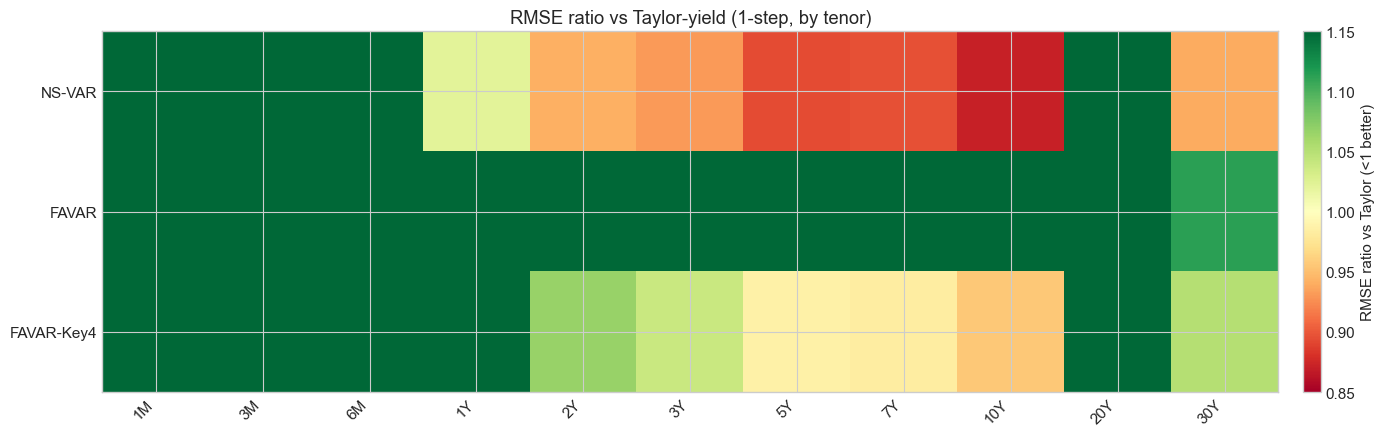

Figure saved: figures/rmse_ratio_vs_taylor_heatmap.png


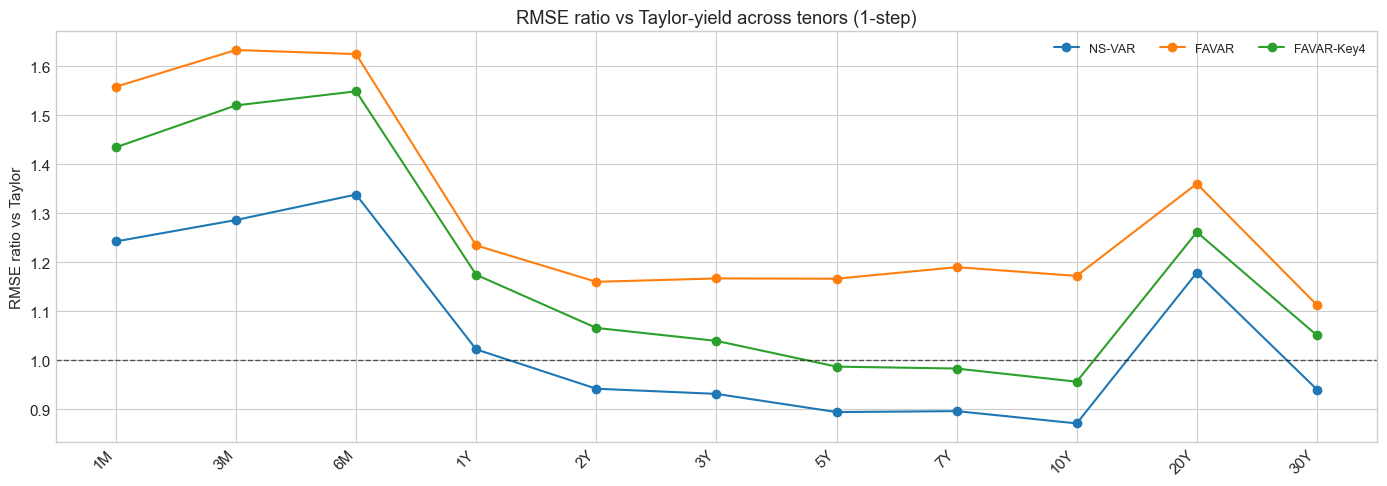

Figure saved: figures/rmse_ratio_vs_taylor_by_tenor_lines.png


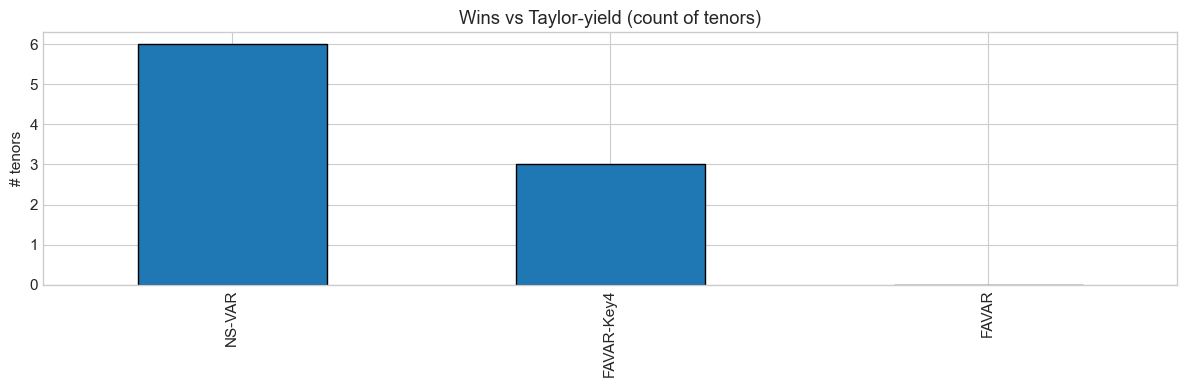

Figure saved: figures/wins_vs_taylor.png


In [37]:
# --- Multi-model yield comparison across tenors (Taylor baseline) ---

# This section reuses the forecasts prepared earlier in the notebook via `yield_model_forecasts`.
# It focuses on: (i) RMSE tables, (ii) ratios vs Taylor, (iii) wins by tenor, and (iv) visuals.

def plot_wins_bar(series, title, filename):
    fig, ax = plt.subplots(figsize=(12, 4))
    series.plot(kind='bar', ax=ax, color='#1f77b4', edgecolor='black')
    ax.set_ylabel('# tenors')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {filename}')


def plot_ratio_heatmap(ratio_df, title, filename, vmin=0.85, vmax=1.15):
    """ratio_df: models x tenors (values are RMSE ratio vs Taylor)."""
    fig, ax = plt.subplots(figsize=(14, 4.5))
    im = ax.imshow(ratio_df.values, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_yticks(range(len(ratio_df.index)))
    ax.set_yticklabels(list(ratio_df.index))
    ax.set_xticks(range(len(ratio_df.columns)))
    ax.set_xticklabels(list(ratio_df.columns), rotation=45, ha='right')
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label('RMSE ratio vs Taylor (<1 better)')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {filename}')


def plot_ratio_lines(ratio_df, title, filename):
    """ratio_df: tenors x models (non-Taylor models)."""
    x = np.arange(len(yield_cols))
    fig, ax = plt.subplots(figsize=(14, 5))
    for name in ratio_df.columns:
        ax.plot(x, ratio_df[name].values, marker='o', linewidth=1.5, label=name)
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.6, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(yield_cols, rotation=45, ha='right')
    ax.set_ylabel('RMSE ratio vs Taylor')
    ax.set_title(title)
    ax.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {filename}')


if 'yield_model_forecasts' not in globals():
    raise RuntimeError("Expected `yield_model_forecasts` to be defined earlier in the notebook.")

# RMSE table: tenors x models
model_names = list(yield_model_forecasts.keys())
rmse_multi = pd.DataFrame(index=yield_cols, columns=model_names, dtype=float)
for tenor in yield_cols:
    for name, fc in yield_model_forecasts.items():
        rmse_multi.loc[tenor, name] = compute_rmse(yields_actual_test[tenor], fc[tenor])

print("\nMulti-model RMSE by tenor (levels):")
display(rmse_multi.round(4))

# RMSE ratios vs Taylor (<1 means better than Taylor)
ratio_vs_taylor = rmse_multi.div(rmse_multi['Taylor Rule'], axis=0)
ratio_vs_taylor = ratio_vs_taylor.drop(columns=['Taylor Rule'])

print("\nRMSE ratio vs Taylor (<1 is improvement):")
display(ratio_vs_taylor.round(4))

# Identify the best FAVAR variant vs Taylor (only among FAVAR candidates)
favar_candidates = [c for c in ratio_vs_taylor.columns if c.startswith('FAVAR_')]
if len(favar_candidates) > 0:
    best_favar_overall = ratio_vs_taylor[favar_candidates].mean(axis=0).idxmin()
    best_favar_avg_ratio = float(ratio_vs_taylor[favar_candidates].mean(axis=0).min())
    yields_forecast_favar_best = yield_model_forecasts[best_favar_overall]
    print(f"\nBest FAVAR variant vs Taylor (lowest avg RMSE ratio): {best_favar_overall} (avg ratio = {best_favar_avg_ratio:.3f})")

# Wins vs Taylor (count tenors with RMSE < Taylor)
wins_vs_taylor = rmse_multi.drop(columns=['Taylor Rule']).lt(rmse_multi['Taylor Rule'], axis=0).sum(axis=0).sort_values(ascending=False)
print("\n# tenors where model beats Taylor-yield:")
display(wins_vs_taylor.to_frame('wins').T)

# Best model per tenor among all models in `rmse_multi`
best_model = rmse_multi.idxmin(axis=1)
print("\nBest (lowest RMSE) model by tenor:")
display(best_model.to_frame('best_model'))

# --- Visualization: heatmap + lines of RMSE ratio vs Taylor ---
heat = ratio_vs_taylor.T  # models x tenors
plot_ratio_heatmap(
    heat,
    title='RMSE ratio vs Taylor-yield (1-step, by tenor)',
    filename='figures/rmse_ratio_vs_taylor_heatmap.png',
    vmin=0.85,
    vmax=1.15,
 )

plot_ratio_lines(
    ratio_vs_taylor,
    title='RMSE ratio vs Taylor-yield across tenors (1-step)',
    filename='figures/rmse_ratio_vs_taylor_by_tenor_lines.png',
 )

# --- Visualization: wins vs Taylor ---
plot_wins_bar(wins_vs_taylor, 'Wins vs Taylor-yield (count of tenors)', 'figures/wins_vs_taylor.png')

---
## 12. Visualizations

Plots for thesis presentation.

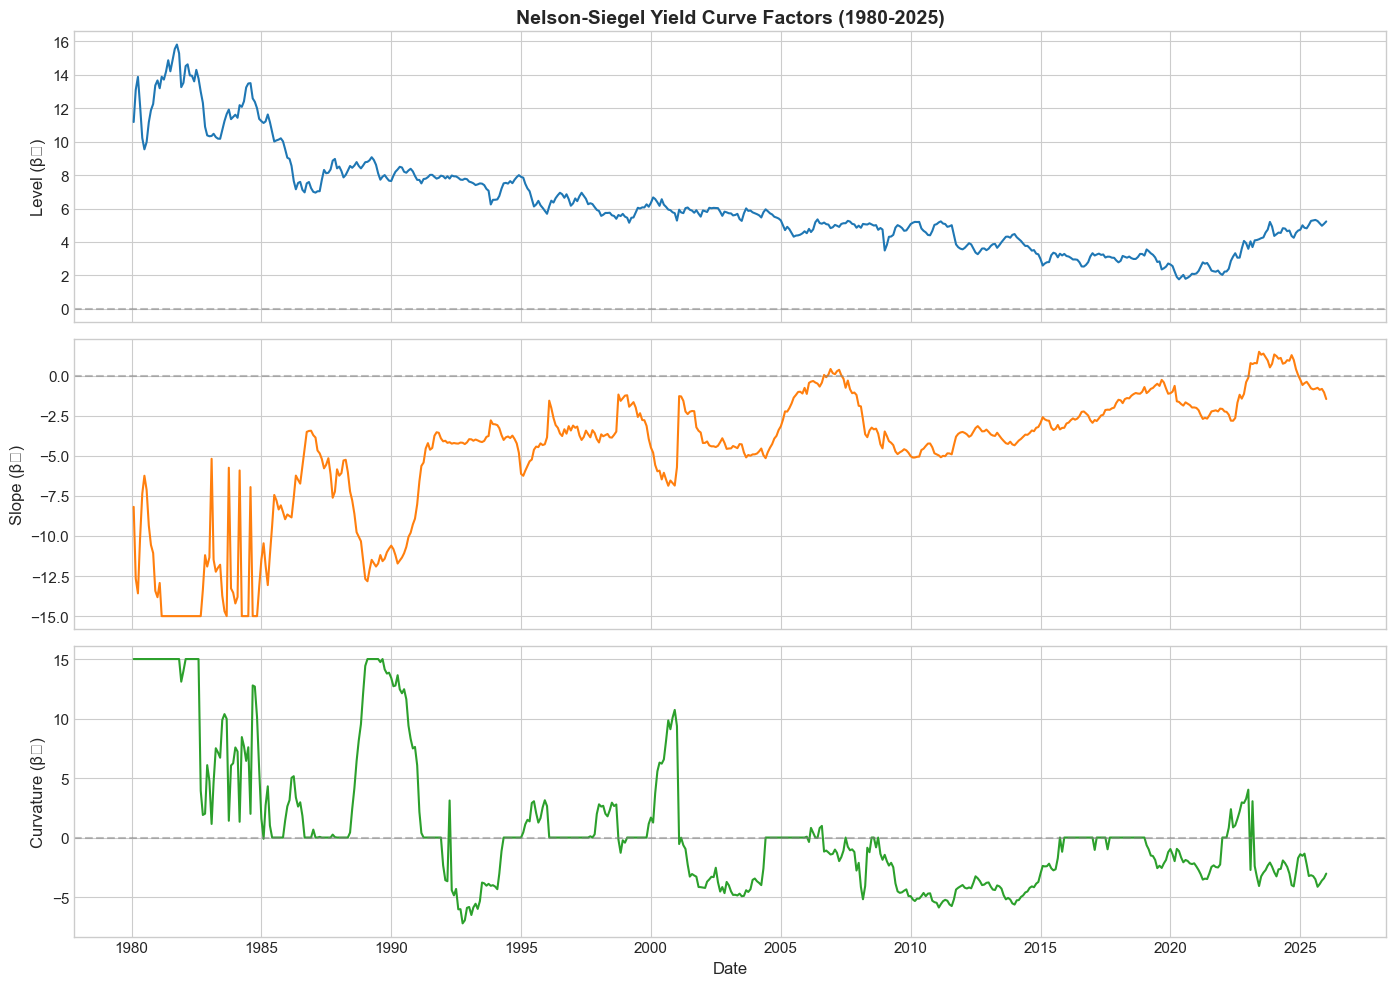

Figure saved: nelson_siegel_factors.png


In [38]:
os.makedirs('figures', exist_ok=True)
# Plot 1: Nelson-Siegel Factors Over Time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

y0, y1 = ns_factors.index.min().year, ns_factors.index.max().year

# Level factor
axes[0].plot(ns_factors.index, ns_factors['level'], color='#1f77b4', linewidth=1.5)
axes[0].set_ylabel('Level (β₀)', fontsize=12)
axes[0].set_title(f'Nelson-Siegel Yield Curve Factors ({y0}-{y1})', fontsize=14, fontweight='bold')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Slope factor
axes[1].plot(ns_factors.index, ns_factors['slope'], color='#ff7f0e', linewidth=1.5)
axes[1].set_ylabel('Slope (β₁)', fontsize=12)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Curvature factor
axes[2].plot(ns_factors.index, ns_factors['curvature'], color='#2ca02c', linewidth=1.5)
axes[2].set_ylabel('Curvature (β₂)', fontsize=12)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/nelson_siegel_factors.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: nelson_siegel_factors.png")

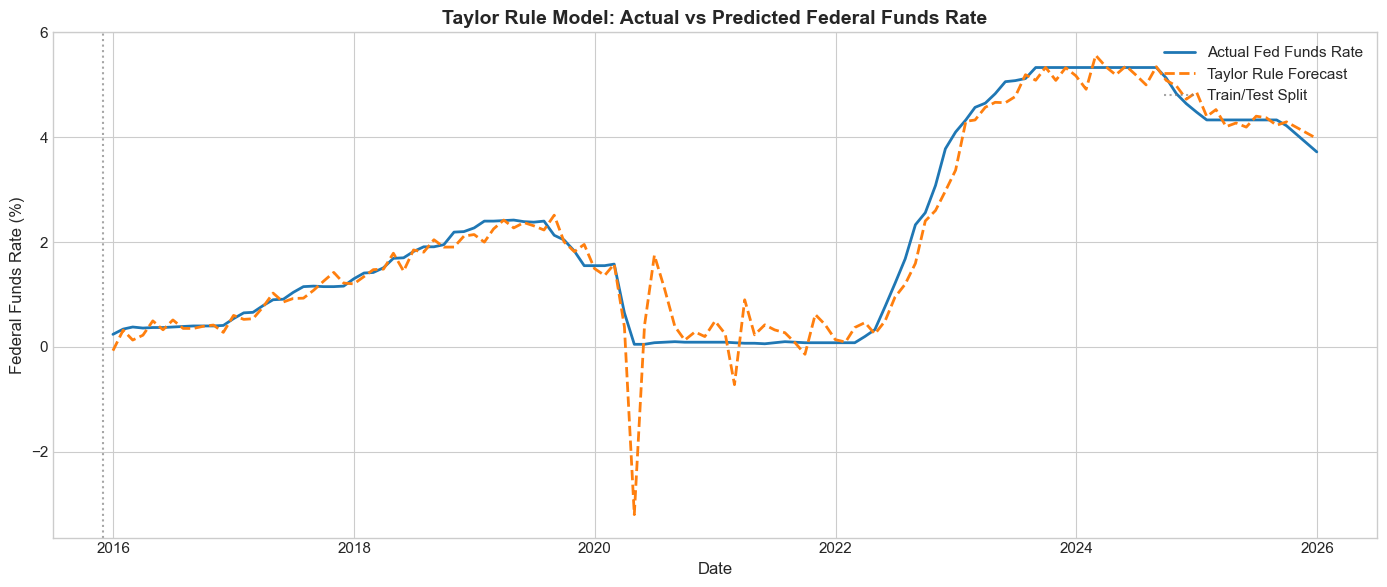

Figure saved: taylor_rule_forecast.png


In [39]:
# Plot 2: Taylor Rule - Actual vs Predicted Fed Funds Rate
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual values
ax.plot(taylor_actual.index, taylor_actual.values, 
        label='Actual Fed Funds Rate', color='#1f77b4', linewidth=2)

# Plot predictions
ax.plot(taylor_actual.index, taylor_forecasts.values, 
        label='Taylor Rule Forecast', color='#ff7f0e', linewidth=2, linestyle='--')

# Add vertical line for train/test split
ax.axvline(x=train_taylor.index[-1], color='gray', linestyle=':', 
           alpha=0.7, label='Train/Test Split')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Federal Funds Rate (%)', fontsize=12)
ax.set_title('Taylor Rule Model: Actual vs Predicted Federal Funds Rate', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('figures/taylor_rule_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: taylor_rule_forecast.png")

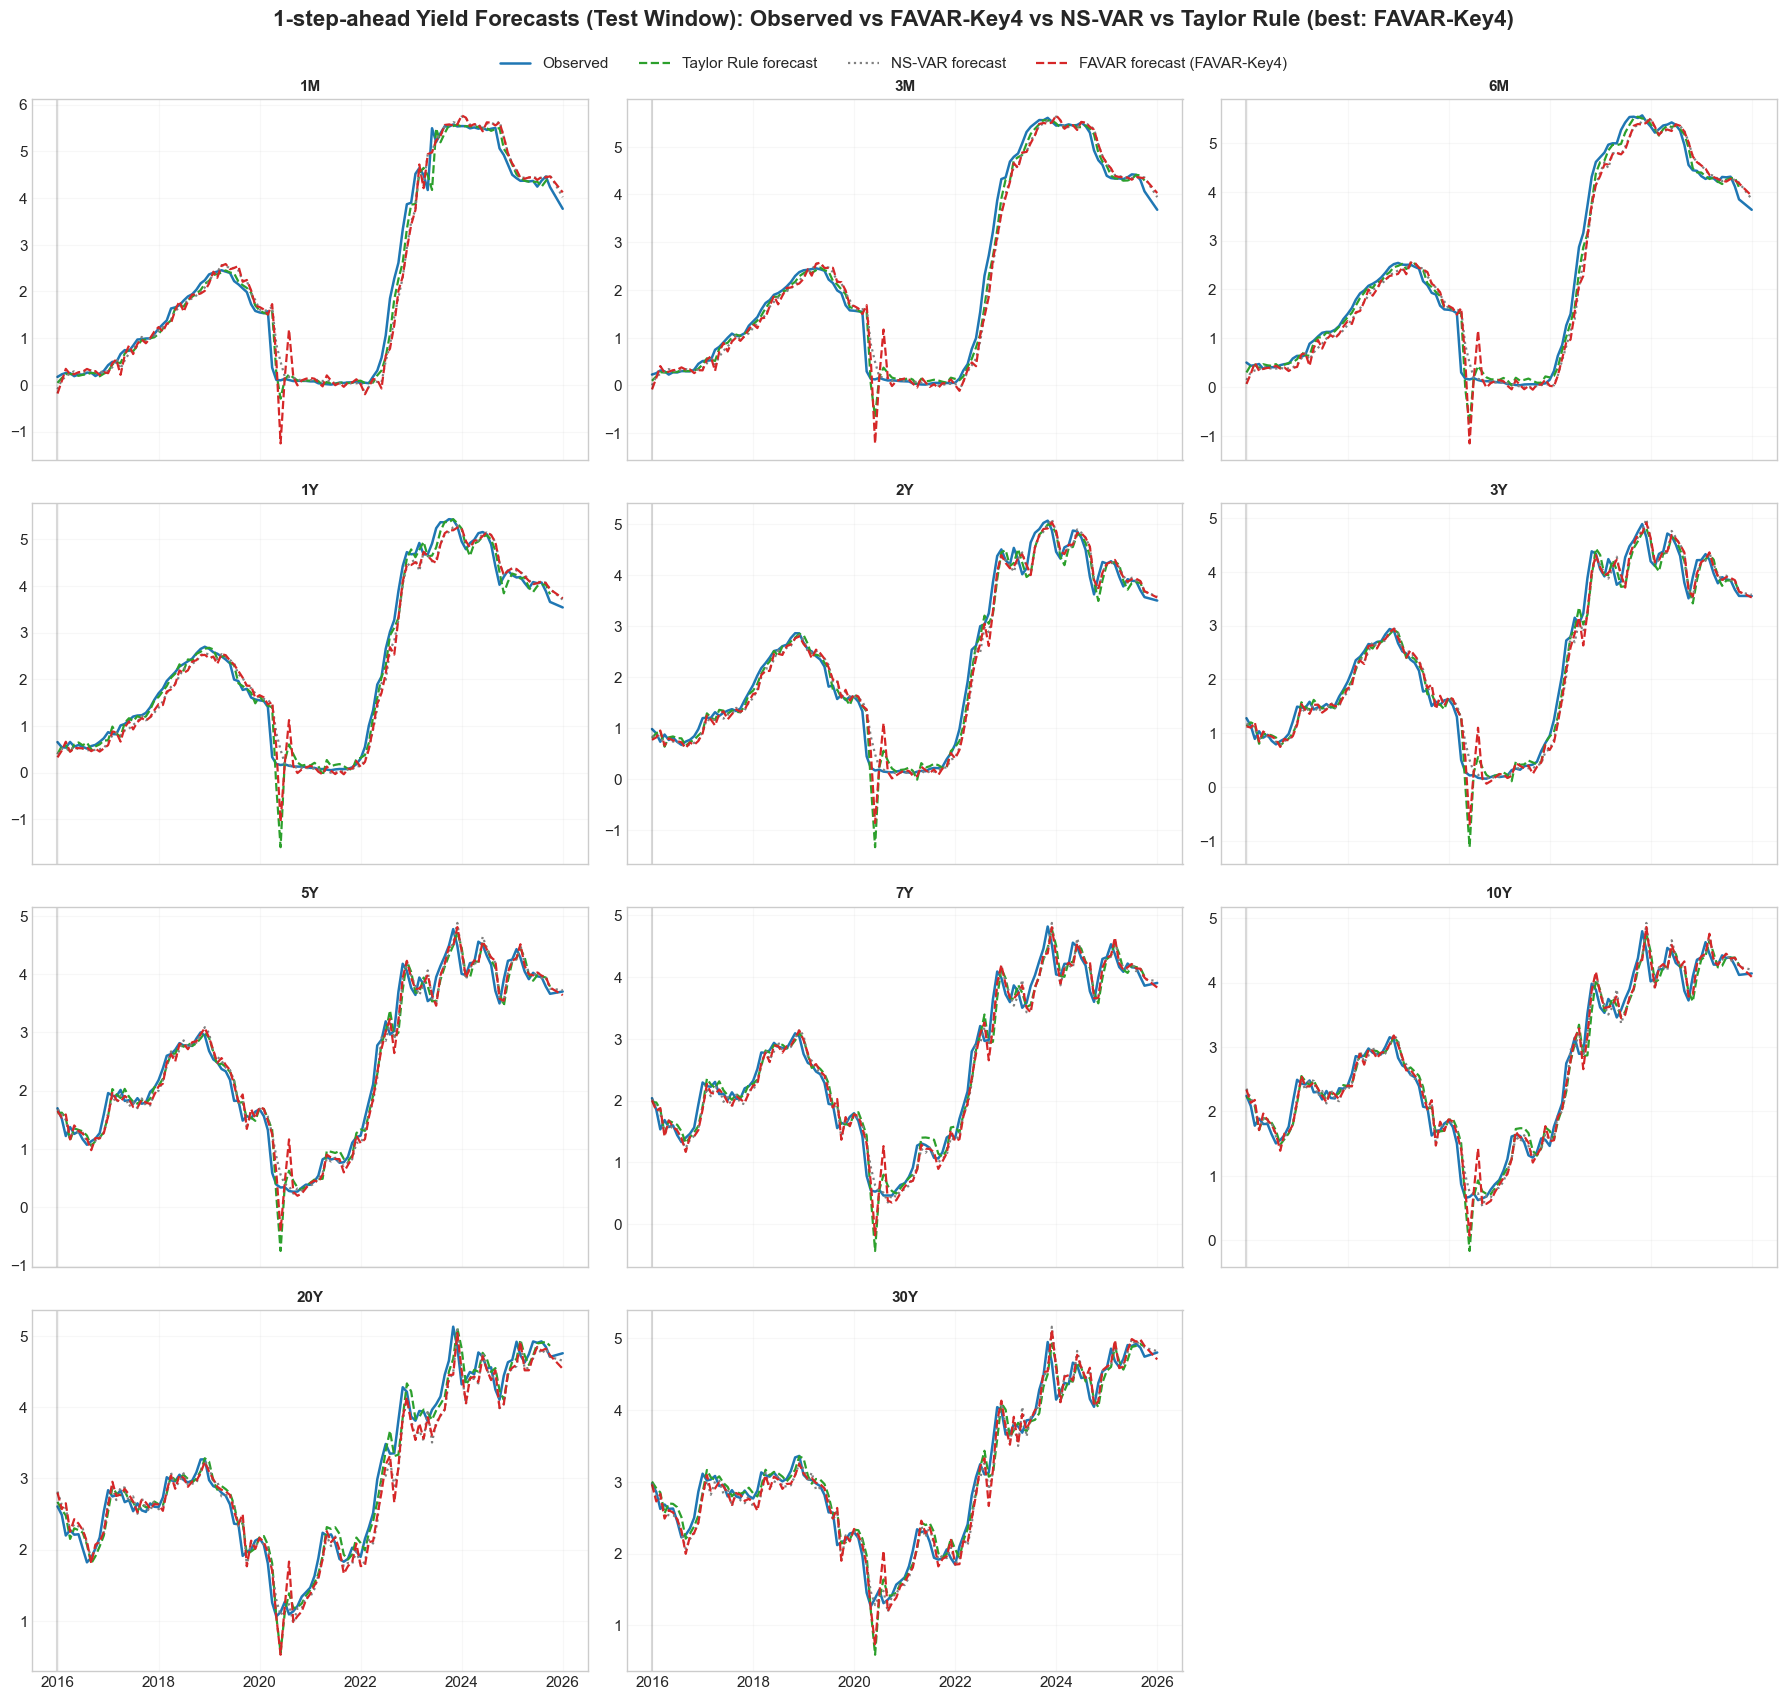

Figure saved: yields_favar_vs_taylor_all_tenors.png


In [40]:
# Plot 3: Observed vs Forecasted yields — best FAVAR vs NS-VAR vs Taylor (for each tenor in the test window)

import math

# Use the best FAVAR variant chosen in the multi-model block (fallback to baseline if needed)
best_favar_name = globals().get('best_favar_overall', None)
favar_fc = globals().get('yields_forecast_favar_best', yields_forecast_favar)
favar_label = f"FAVAR forecast ({best_favar_name})" if best_favar_name else "FAVAR forecast"

n = len(yield_cols)
ncols = 3
nrows = int(math.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(yield_cols):
    ax = axes[i]
    ax.plot(
        yields_actual_test.index,
        yields_actual_test[col].values,
        color='#1f77b4',
        linewidth=1.8,
        label='Observed' if i == 0 else None,
    )
    ax.plot(
        yields_actual_test.index,
        yields_forecast_taylor[col].reindex(yields_actual_test.index).values,
        color='#2ca02c',
        linewidth=1.6,
        linestyle='--',
        label='Taylor Rule forecast' if i == 0 else None,
    )
    ax.plot(
        yields_actual_test.index,
        yields_forecast_nsvar[col].reindex(yields_actual_test.index).values,
        color='gray',
        linewidth=1.6,
        linestyle=':',
        label='NS-VAR forecast' if i == 0 else None,
    )
    ax.plot(
        yields_actual_test.index,
        favar_fc[col].reindex(yields_actual_test.index).values,
        color='#d62728',
        linewidth=1.6,
        linestyle='--',
        label=favar_label if i == 0 else None,
    )
    ax.axvline(x=split_date, color='black', linestyle='-', alpha=0.15)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.15)

# Turn off any unused subplots
for j in range(n, len(axes)):
    axes[j].axis('off')

title_suffix = f" (best: {best_favar_name})" if best_favar_name else ""
fig.suptitle(
    f"1-step-ahead Yield Forecasts (Test Window): Observed vs FAVAR-Key4 vs NS-VAR vs Taylor Rule{title_suffix}",
    fontsize=16,
    fontweight='bold',
    y=1.01,
 )
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.99), frameon=False)

plt.tight_layout()
plt.savefig('figures/yields_favar_vs_taylor_all_tenors.png', dpi=300, bbox_inches='tight')
plt.show()

print('Figure saved: yields_favar_vs_taylor_all_tenors.png')

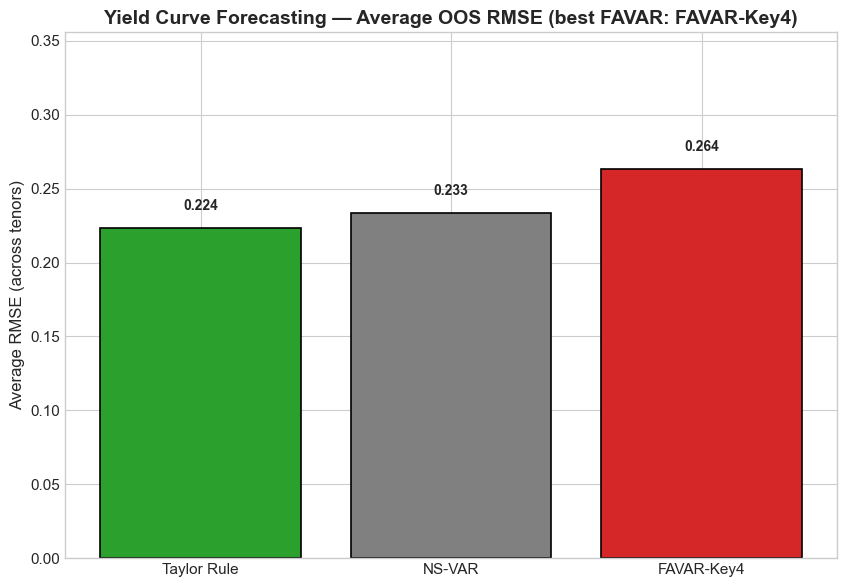

Figure saved: avg_rmse_favar_vs_taylor.png


In [41]:
# Plot 4: Average RMSE Comparison — Taylor vs NS-VAR vs best FAVAR (Yield Curve)
fig, ax = plt.subplots(figsize=(8.6, 6))

best_favar_name = globals().get('best_favar_overall', None)
rmse_values = None
models = None

if 'rmse_multi' in globals() and best_favar_name is not None and best_favar_name in rmse_multi.columns:
    models = ['Taylor Rule', 'NS-VAR', best_favar_name]
    rmse_values = [float(rmse_multi[m].mean()) for m in models]
elif 'yield_rmse_ft_df' in globals() and best_favar_name is not None and best_favar_name in yield_rmse_ft_df.columns and 'NS-VAR' in yield_rmse_ft_df.columns:
    models = ['Taylor Rule', 'NS-VAR', best_favar_name]
    rmse_values = [float(yield_rmse_ft_df[m].mean()) for m in models]
else:
    # Fallback to baseline headline comparison
    models = ['Taylor', 'NS-VAR', 'FAVAR']
    rmse_values = [
        float(pd.Series([compute_rmse(yields_actual_test[t], yields_forecast_taylor[t]) for t in yield_cols]).mean()),
        float(pd.Series([compute_rmse(yields_actual_test[t], yields_forecast_nsvar[t]) for t in yield_cols]).mean()),
        float(pd.Series([compute_rmse(yields_actual_test[t], yields_forecast_favar[t]) for t in yield_cols]).mean()),
    ]

colors = ['#2ca02c', 'gray', '#d62728']
bars = ax.bar(models, rmse_values, color=colors, edgecolor='black', linewidth=1.2)

for bar, val in zip(bars, rmse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
    )

ax.set_ylabel('Average RMSE (across tenors)', fontsize=12)
title_suffix = f" (best FAVAR: {best_favar_name})" if best_favar_name else ""
ax.set_title(f'Yield Curve Forecasting — Average OOS RMSE{title_suffix}', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(rmse_values) * 1.35)

plt.tight_layout()
plt.savefig('figures/avg_rmse_favar_vs_taylor.png', dpi=300, bbox_inches='tight')
plt.show()

print('Figure saved: avg_rmse_favar_vs_taylor.png')

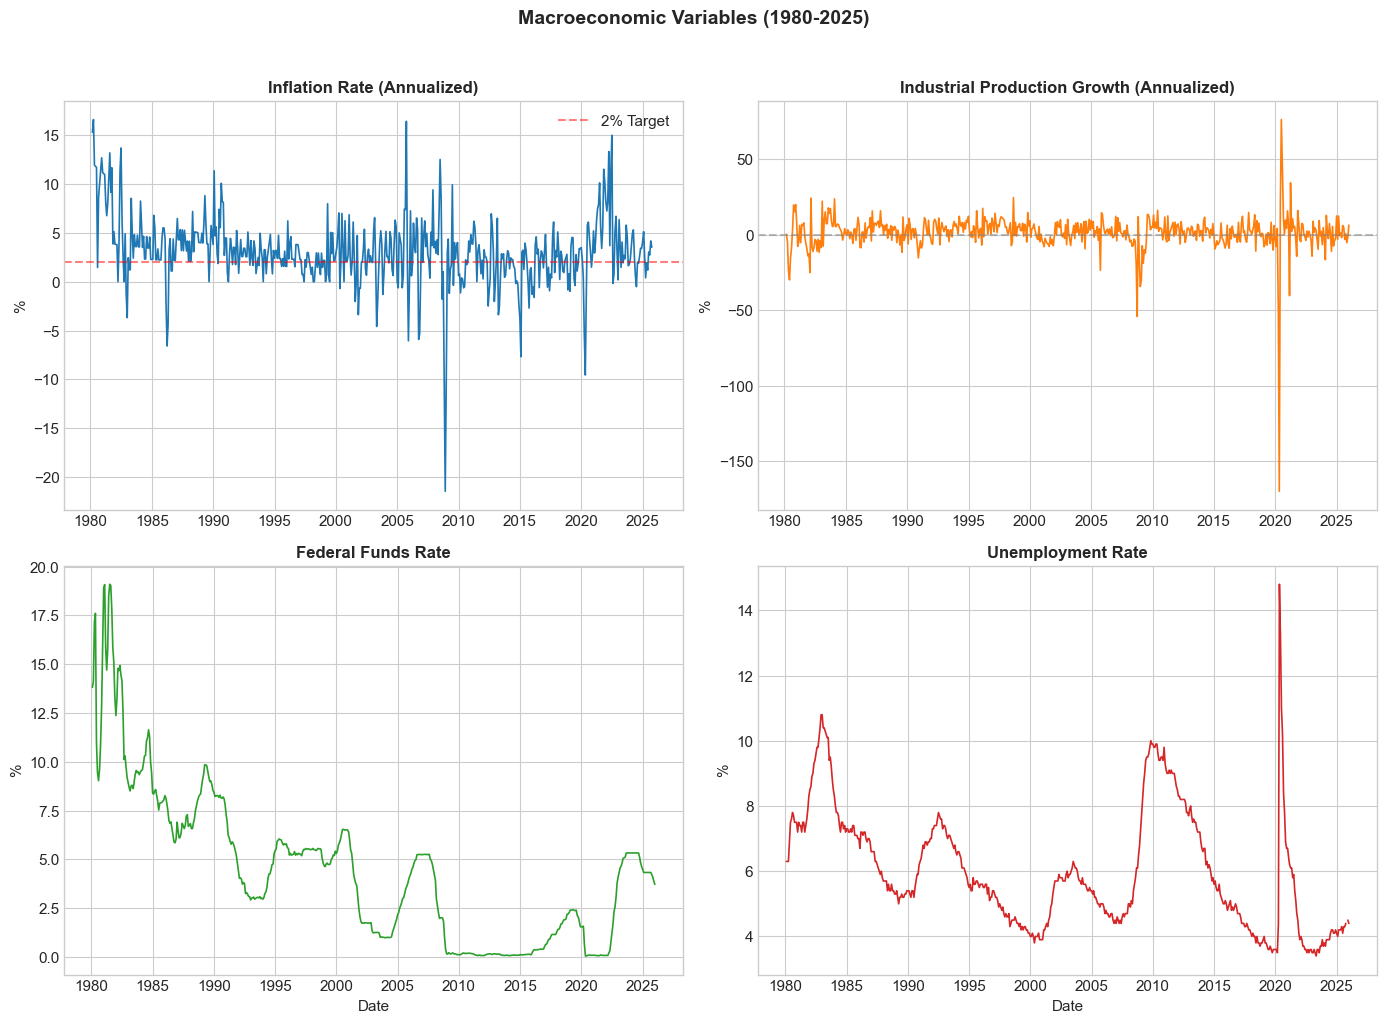

Figure saved: macro_variables.png


In [42]:
# Plot 5: Macro Variables Over Time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

y0, y1 = macro_aligned.index.min().year, macro_aligned.index.max().year

# Inflation
axes[0, 0].plot(macro_aligned.index, macro_aligned['inflation'], color='#1f77b4', linewidth=1.2)
axes[0, 0].set_title('Inflation Rate (Annualized)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('%')
axes[0, 0].axhline(y=2, color='red', linestyle='--', alpha=0.5, label='2% Target')
axes[0, 0].legend()

# Output Growth
axes[0, 1].plot(macro_aligned.index, macro_aligned['output'], color='#ff7f0e', linewidth=1.2)
axes[0, 1].set_title('Industrial Production Growth (Annualized)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('%')
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Fed Funds Rate
axes[1, 0].plot(macro_aligned.index, macro_aligned['fedfunds'], color='#2ca02c', linewidth=1.2)
axes[1, 0].set_title('Federal Funds Rate', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('%')
axes[1, 0].set_xlabel('Date')

# Unemployment Rate
axes[1, 1].plot(macro_aligned.index, macro_aligned['unrate'], color='#d62728', linewidth=1.2)
axes[1, 1].set_title('Unemployment Rate', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('%')
axes[1, 1].set_xlabel('Date')

plt.suptitle(f'Macroeconomic Variables ({y0}-{y1})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/macro_variables.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: macro_variables.png")

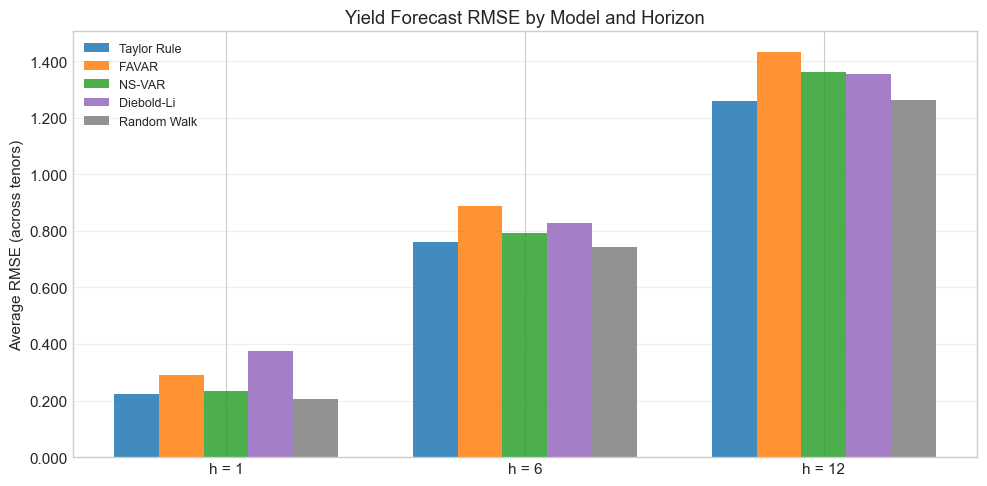

Figure saved: multi_horizon_rmse.png


In [43]:
# =============================================================================
# VISUALIZATION: Average RMSE by horizon (grouped bar chart)
# =============================================================================
import matplotlib.ticker as mticker

models_to_plot = ['Taylor Rule', 'FAVAR', 'NS-VAR', 'Diebold-Li', 'Random Walk']
colors = {'Taylor Rule': '#1f77b4', 'FAVAR': '#ff7f0e', 'NS-VAR': '#2ca02c',
          'Diebold-Li': '#9467bd', 'Random Walk': '#7f7f7f'}

x       = np.arange(len(HORIZONS))
width   = 0.15
offsets = np.linspace(-(len(models_to_plot) - 1) * width / 2,
                       (len(models_to_plot) - 1) * width / 2,
                       len(models_to_plot))

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(models_to_plot):
    vals = [rmse_summary.loc[name, f'h={h}'] for h in HORIZONS]
    ax.bar(x + offsets[i], vals, width, label=name,
           color=colors.get(name), alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'h = {h}' for h in HORIZONS])
ax.set_ylabel('Average RMSE (across tenors)')
ax.set_title('Yield Forecast RMSE by Model and Horizon')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/multi_horizon_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: multi_horizon_rmse.png')


---
## Summary

**Research question:** Does FAVAR (NS-VAR + macro factors) improve yield-curve forecasts over NS-VAR alone?
Is FAVAR better than the **Taylor Rule benchmark** (strict 3-variable OLS)?

### Main findings

1. **NS-VAR and FAVAR beat Taylor Rule at most tenors (h=1).**
2. **NS-VAR outperforms FAVAR** — adding macro PCA factors does NOT help (RMSE increases from 0.23 to 0.29).
3. **Expanding the macro panel (25 series, 4 factors) makes FAVAR worse**, not better.
4. **No model consistently beats Random Walk** at any horizon.
5. **Taylor collapses at h=6,12** (RMSE 2.29/3.01 vs RW 0.74/1.26) — direct OLS degrades badly at longer horizons.

### Interpretation

Yield-curve dynamics are largely self-contained: the NS factors already subsume the macro information relevant for
yield forecasting. Adding macro factors introduces noise (overparameterization) rather than signal.
This is consistent with Duffee (2002) and Diebold & Li (2006): yields are close to random walks,
and macro information adds little once you condition on the yield curve itself.

### Next steps

- Diebold-Mariano significance tests for key pairwise comparisons
- Sub-period analysis (ZLB era, 2022 hiking cycle)
- Strict Taylor rule benchmark (inflation + output gap + lagged rate only)
- Bayesian VAR for FAVAR (shrinkage may help with the dimensionality problem)


In [44]:
# Final summary statistics
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(f"Data Period (aligned): {common_index[0].strftime('%Y-%m')} to {common_index[-1].strftime('%Y-%m')}")
print(f"Total Observations (monthly): {len(common_index)}")
print(f"Test Window (yields): {test_dates[0].strftime('%Y-%m')} to {test_dates[-1].strftime('%Y-%m')}")
print(f"Train/Test Split Date: {split_date.strftime('%Y-%m')}")

print(f"\nVAR Lag Order: {VAR_LAGS}")
print(f"PCA Components: {pca_model.n_components_} (Explained Variance: {sum(variance_ratios)*100:.1f}%)")
print("NS lambda handling in yield reconstruction: random-walk (lambda_t = lambda_(t-1))")
print(f"Median lambda in sample: {ns_factors['lambda'].median():.4f}")

print("\n" + "-" * 70)
print("YIELD CURVE OUT-OF-SAMPLE PERFORMANCE (Taylor Rule vs NS-VAR vs FAVAR-Key4)")
print("-" * 70)

favar_name = best_favar_overall
core_cols = ['Taylor Rule', 'NS-VAR', favar_name]

avg_rmse = yield_rmse_ft_df[core_cols].mean(axis=0).round(4)
avg_mae = yield_mae_ft_df[core_cols].mean(axis=0).round(4)

print(f"Best FAVAR spec (vs Taylor Rule benchmark): {favar_name}")
print("\nAverage RMSE across tenors:")
print(avg_rmse.to_string())
print("\nAverage MAE across tenors:")
print(avg_mae.to_string())

# Pairwise diagnostics vs Taylor
for name in ['NS-VAR', favar_name]:
    avg_rel = float((yield_rmse_ft_df[name] / yield_rmse_ft_df['Taylor Rule']).mean())
    wins_rmse = int((yield_rmse_ft_df[name] < yield_rmse_ft_df['Taylor Rule']).sum())
    wins_mae = int((yield_mae_ft_df[name] < yield_mae_ft_df['Taylor Rule']).sum())
    avg_wr = float(yield_winrate_vs_taylor[name].mean())
    label = name
    if name == favar_name:
        label = f"Best FAVAR ({favar_name})"
    print(f"\nDiagnostics vs Taylor (yields) — {label}:")
    print(f"  Avg RMSE ratio (model/Taylor): {avg_rel:.4f}  (<1 favors model)")
    print(f"  # tenors model beats Taylor (RMSE): {wins_rmse} / {len(yield_cols)}")
    print(f"  # tenors model beats Taylor (MAE):  {wins_mae} / {len(yield_cols)}")
    print(f"  Avg win-rate P(|e_model| < |e_Taylor|): {avg_wr:.3f}")

# Best model counts (lowest RMSE among the 3 core models)
best_model_by_tenor = yield_rmse_ft_df[core_cols].idxmin(axis=1)
counts = best_model_by_tenor.value_counts()
print("\nBest model by tenor (lowest RMSE among Taylor / NS-VAR / best FAVAR):")
print(counts.to_string())

print("\n" + "-" * 70)
print("FED FUNDS (TAYLOR RULE) OUT-OF-SAMPLE")
print("-" * 70)
print(f"Taylor RMSE: {taylor_rmse:.4f}")

print("=" * 70)


FINAL SUMMARY
Data Period (aligned): 1980-01 to 2025-12
Total Observations (monthly): 552
Test Window (yields): 2015-12 to 2025-12
Train/Test Split Date: 2015-12

VAR Lag Order: 2
PCA Components: 3 (Explained Variance: 53.0%)
NS lambda handling in yield reconstruction: random-walk (lambda_t = lambda_(t-1))
Median lambda in sample: 1.2172

----------------------------------------------------------------------
YIELD CURVE OUT-OF-SAMPLE PERFORMANCE (Taylor Rule vs NS-VAR vs FAVAR-Key4)
----------------------------------------------------------------------
Best FAVAR spec (vs Taylor Rule benchmark): FAVAR-Key4

Average RMSE across tenors:
Taylor Rule    0.2235
NS-VAR         0.2335
FAVAR-Key4     0.2636

Average MAE across tenors:
Taylor Rule    0.1459
NS-VAR         0.1655
FAVAR-Key4     0.1817

Diagnostics vs Taylor (yields) — NS-VAR:
  Avg RMSE ratio (model/Taylor): 1.0493  (<1 favors model)
  # tenors model beats Taylor (RMSE): 6 / 11
  # tenors model beats Taylor (MAE):  4 / 11
  Avg